<a href="https://colab.research.google.com/github/habibiputrar/BigData26_A_2411531001_Habibi-Putra-Rizqullah-/blob/main/Praktikum3/BD_P03_2411531001_Habibi_Putra_Rizqullah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K. Tutorial Langkah demi Langkah**


In [1]:
!pip install sqlalchemy

### **K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1**

**Tujuan.** Memastikan seluruh pustaka dapat digunakan, menghubungkan Google Drive, menyiapkan folder kerja, serta membuat fungsi pengukuran waktu, memori, dan lineage.

**Keputusan.** Data mentah ditempatkan pada `/content/lapisan_mentah`, sedangkan hasil kurasi disimpan terpisah pada `/content/lapisan_terkurasi`. Artefak penting disalin ke Google Drive karena penyimpanan `/content` bersifat sementara.

In [2]:
# K-1: Menyiapkan lingkungan kerja

import sys
import time
import os
import json
import sqlite3
import gc

import pandas as pd
import numpy as np
import psutil

# Menampilkan versi Python
print("Python     :", sys.version.split()[0])

# Memeriksa versi pustaka yang diperlukan
for nama in [
    "pandas",
    "numpy",
    "pyarrow",
    "requests",
    "sklearn",
    "sqlalchemy"
]:
    try:
        modul = __import__(nama)
        print(f"{nama:11s}: {modul.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Menentukan direktori kerja
DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"

# Membuat direktori jika belum tersedia
for direktori in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(direktori, exist_ok=True)

print("\nFolder kerja:")
print("Data mentah :", DIR_MENTAH, os.path.exists(DIR_MENTAH))
print("Data kurasi :", DIR_KURASI, os.path.exists(DIR_KURASI))
print("Penyimpanan :", DIR_SIMPAN, os.path.exists(DIR_SIMPAN))

# Menyiapkan pengukuran waktu dan penggunaan memori
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    memori_awal = rss_mb()
    waktu_awal = time.perf_counter()

    hasil = fungsi()

    detik = time.perf_counter() - waktu_awal
    delta_memori = rss_mb() - memori_awal

    catatan.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(delta_memori, 1)
    })

    print(
        f"[{label}] {detik:.2f} detik | "
        f"delta RSS: {delta_memori:.1f} MB"
    )

    return hasil

# Menyiapkan pencatatan asal-usul data
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama,
        "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris,
        "keterangan": keterangan
    })

    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

print("\nK-1 selesai: lingkungan kerja telah disiapkan.")

Python     : 3.13.15
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.52
Mounted at /content/drive

Folder kerja:
Data mentah : /content/lapisan_mentah True
Data kurasi : /content/lapisan_terkurasi True
Penyimpanan : /content/drive/MyDrive/BigData/Praktikum3 True

K-1 selesai: lingkungan kerja telah disiapkan.


#### **Pembahasan Hasil**

Langkah ini dilakukan untuk memeriksa versi pustaka, menghubungkan Google Drive,
menyiapkan folder kerja, serta membuat fungsi pengukuran waktu, memori, dan
pencatatan asal-usul data.

Data mentah dan data hasil pengolahan disimpan pada folder yang berbeda agar
data asli tetap tersedia dan tidak tertimpa selama proses pra-pemrosesan.

### **K-2. Akuisisi 1 - Unduhan Berkala yang Tahan Gagal**

**Tujuan.** Mengunduh data perjalanan dan tabel zona dengan mekanisme yang tetap aman ketika koneksi terputus.

**Keputusan.** Cache hanya dipakai jika berkas tersedia, tidak kosong, dan masih dapat dibaca. Unduhan baru ditulis ke berkas `.part`, dicoba maksimal tiga kali dengan jeda bertambah, lalu dipindahkan secara atomik ke nama akhir.

In [3]:
# K-2: Akuisisi data dengan cache, retry, dan penulisan atomik

import requests
import pyarrow.parquet as pq

# Mengurangi penggunaan memori jika K-2 sebelumnya pernah dijalankan
if "trip" in globals():
    del trip
    gc.collect()


def cache_valid(path):
    """
    Memeriksa apakah berkas cache tersedia dan dapat dibaca.
    """

    if not os.path.exists(path):
        return False

    if os.path.getsize(path) == 0:
        return False

    try:
        if path.endswith(".csv"):
            pd.read_csv(path, nrows=2)

        elif path.endswith(".parquet"):
            pq.ParquetFile(path).metadata

        return True

    except Exception as error:
        print(
            "Cache tidak valid:",
            os.path.basename(path),
            f"({error})"
        )
        return False


def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """
    Mengunduh berkas dengan cache, retry,
    dan penulisan atomik.
    """

    # Memakai cache jika berkas tersedia dan dapat dibaca
    if cache_valid(tujuan):
        print("Cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            with requests.get(
                url,
                stream=True,
                timeout=60
            ) as respons:

                respons.raise_for_status()

                # Menyimpan data sedikit demi sedikit
                with open(sementara, "wb") as berkas:
                    for potongan in respons.iter_content(
                        chunk_size=1024 * 1024
                    ):
                        if potongan:
                            berkas.write(potongan)

                # Memastikan hasil unduhan tidak kosong
                if os.path.getsize(sementara) == 0:
                    raise IOError("Berkas hasil unduhan kosong")

                # Mengganti cache lama dengan berkas baru
                os.replace(sementara, tujuan)

                # Memastikan berkas baru dapat dibaca
                if not cache_valid(tujuan):
                    raise IOError(
                        "Berkas selesai diunduh, tetapi tidak dapat dibaca"
                    )

                print(
                    "Unduhan selesai:",
                    os.path.basename(tujuan)
                )

                return tujuan

        except Exception as error:
            # Menghapus berkas sementara jika proses gagal
            if os.path.exists(sementara):
                os.remove(sementara)

            jeda = jeda_awal * (2 ** i)

            print(
                f"Percobaan {i + 1} gagal ({error}); "
                f"menunggu {jeda} detik"
            )

            if i < percobaan - 1:
                time.sleep(jeda)

    raise RuntimeError(
        f"Gagal mengunduh setelah {percobaan} percobaan: {url}"
    )


# URL sumber resmi NYC TLC
URL_TRIP = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "trip-data/yellow_tripdata_2023-01.parquet"
)

URL_ZONA = (
    "https://d37ci6vzurychx.cloudfront.net/"
    "misc/taxi_zone_lookup.csv"
)


# Lokasi penyimpanan data mentah
PATH_TRIP = os.path.join(
    DIR_MENTAH,
    "yellow_tripdata_2023-01.parquet"
)

PATH_ZONA = os.path.join(
    DIR_MENTAH,
    "taxi_zone_lookup.csv"
)


# Mengunduh dataset perjalanan dan tabel zona
ukur(
    "unduh trip",
    lambda: unduh_aman(URL_TRIP, PATH_TRIP)
)

ukur(
    "unduh zona",
    lambda: unduh_aman(URL_ZONA, PATH_ZONA)
)


# Menampilkan ukuran berkas
print("\nUkuran berkas:")

for path in (PATH_TRIP, PATH_ZONA):
    ukuran_byte = os.path.getsize(path)
    ukuran_mb = ukuran_byte / 1024**2

    print(
        f"{os.path.basename(path)} -> "
        f"{ukuran_mb:.4f} MB "
        f"({ukuran_byte:,} byte)"
    )


# Daftar kolom yang diperlukan
KOLOM = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount"
]


# Membaca dataset perjalanan
trip = ukur(
    "baca trip",
    lambda: pd.read_parquet(
        PATH_TRIP,
        columns=KOLOM
    )
)


# Membaca tabel zona
zona = pd.read_csv(PATH_ZONA)


# Menghindari duplikasi lineage jika sel dijalankan ulang
lineage[:] = [
    item for item in lineage
    if item["sumber"] not in ("trip", "zona")
]


# Mencatat asal-usul data
catat_sumber(
    "trip",
    URL_TRIP,
    len(trip),
    "Parquet bulanan NYC TLC"
)

catat_sumber(
    "zona",
    URL_ZONA,
    len(zona),
    "Tabel referensi zona NYC TLC"
)


# Menampilkan informasi dataset
print("\nInformasi dataset:")

print(
    f"Dataset trip : {trip.shape[0]:,} baris "
    f"x {trip.shape[1]} kolom"
)

print(
    f"Tabel zona  : {zona.shape[0]:,} baris "
    f"x {zona.shape[1]} kolom"
)

print("\nKolom dataset trip:")
print(trip.columns.tolist())

print("\nLima baris pertama tabel zona:")
display(zona.head())

Unduhan selesai: yellow_tripdata_2023-01.parquet
[unduh trip] 0.44 detik | delta RSS: 4.9 MB
Unduhan selesai: taxi_zone_lookup.csv
[unduh zona] 0.06 detik | delta RSS: 0.9 MB

Ukuran berkas:
yellow_tripdata_2023-01.parquet -> 45.4649 MB (47,673,370 byte)
taxi_zone_lookup.csv -> 0.0118 MB (12,331 byte)
[baca trip] 1.66 detik | delta RSS: 266.2 MB
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris

Informasi dataset:
Dataset trip : 3,066,766 baris x 10 kolom
Tabel zona  : 265 baris x 4 kolom

Kolom dataset trip:
['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'tip_amount', 'total_amount']

Lima baris pertama tabel zona:


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


#### **Pembahasan Hasil**

Langkah ini bertujuan mengunduh dataset perjalanan taksi dan tabel referensi
zona secara aman. Dataset diunduh ke berkas sementara terlebih dahulu agar
berkas utama tidak rusak apabila koneksi terputus.

Mekanisme cache digunakan agar dataset yang sudah tersedia tidak diunduh
kembali. Apabila terjadi kegagalan sementara, proses unduh akan diulang dengan
waktu tunggu yang bertambah pada setiap percobaan.

### **K-3. Akuisisi 2 - Memanggil API JSON**

**Tujuan.** Mengambil suhu dan curah hujan per jam dari Open-Meteo untuk New York City selama Januari 2023.

**Keputusan.** Zona waktu menggunakan `America/New_York` agar sesuai dengan waktu perjalanan. Respons hanya diterima jika memiliki bagian `hourly` dan kolom wajib. Status sementara seperti 429 dan 5xx dicoba ulang, sedangkan galat lain langsung dihentikan.

In [4]:
# K-3: Mengambil data cuaca melalui API

API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(
    tanggal_mulai,
    tanggal_selesai,
    latitude=40.7128,
    longitude=-74.0060,
    maksimum_percobaan=3
):
    parameter = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": tanggal_mulai,
        "end_date": tanggal_selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York"
    }

    for percobaan_ke in range(1, maksimum_percobaan + 1):
        try:
            respons = requests.get(
                API_CUACA,
                params=parameter,
                timeout=60
            )

            # Respons berhasil
            if respons.status_code == 200:
                data_json = respons.json()

                if "hourly" not in data_json:
                    raise ValueError(
                        "Bagian 'hourly' tidak ditemukan pada respons API."
                    )

                data_cuaca = pd.DataFrame(data_json["hourly"])

                kolom_wajib = {
                    "time",
                    "temperature_2m",
                    "precipitation"
                }

                kolom_hilang = kolom_wajib - set(data_cuaca.columns)

                if kolom_hilang:
                    raise ValueError(
                        f"Kolom cuaca tidak lengkap: {kolom_hilang}"
                    )

                return data_cuaca

            # Status sementara yang masih layak dicoba ulang
            if respons.status_code in (429, 500, 502, 503, 504):
                waktu_tunggu = 2 ** (percobaan_ke - 1)

                print(
                    f"Percobaan {percobaan_ke} gagal "
                    f"dengan status {respons.status_code}. "
                    f"Mencoba kembali dalam {waktu_tunggu} detik."
                )

                time.sleep(waktu_tunggu)
                continue

            # Memunculkan error untuk status selain yang ditangani
            respons.raise_for_status()

        except requests.RequestException as error:
            if percobaan_ke == maksimum_percobaan:
                raise RuntimeError(
                    "Data cuaca gagal diambil setelah "
                    f"{maksimum_percobaan} percobaan."
                ) from error

            waktu_tunggu = 2 ** (percobaan_ke - 1)

            print(
                f"Terjadi gangguan koneksi: {error}. "
                f"Mencoba kembali dalam {waktu_tunggu} detik."
            )

            time.sleep(waktu_tunggu)

    raise RuntimeError("API cuaca tidak memberikan respons yang valid.")


# Mengambil data cuaca Januari 2023
cuaca = ukur(
    "ambil cuaca",
    lambda: ambil_cuaca("2023-01-01", "2023-01-31")
)

# Mengubah kolom waktu menjadi datetime
cuaca["time"] = pd.to_datetime(
    cuaca["time"],
    errors="coerce"
)

if cuaca["time"].isna().any():
    raise ValueError(
        "Terdapat nilai waktu cuaca yang gagal dikonversi."
    )

# Mengganti nama kolom agar lebih ringkas
cuaca = cuaca.rename(
    columns={
        "time": "jam_mulai",
        "temperature_2m": "suhu_c",
        "precipitation": "hujan_mm"
    }
)

# Mencegah duplikasi catatan apabila cell dijalankan ulang
lineage[:] = [
    item for item in lineage
    if item["sumber"] != "cuaca"
]

# Mencatat asal-usul data
catat_sumber(
    nama="cuaca",
    asal=API_CUACA,
    jumlah_baris=len(cuaca),
    keterangan="Open-Meteo hourly archive untuk New York City"
)

# Menampilkan hasil pemeriksaan
print("\nInformasi data cuaca:")
print(f"Jumlah baris : {len(cuaca):,}")
print(f"Jumlah kolom : {cuaca.shape[1]}")
print(
    "Rentang waktu:",
    cuaca["jam_mulai"].min(),
    "s.d.",
    cuaca["jam_mulai"].max()
)

print("\nJumlah nilai kosong:")
print(cuaca.isna().sum())

print("\nLima baris pertama:")
display(cuaca.head())

[ambil cuaca] 0.53 detik | delta RSS: 0.1 MB
[lineage] cuaca: 744 baris

Informasi data cuaca:
Jumlah baris : 744
Jumlah kolom : 3
Rentang waktu: 2023-01-01 00:00:00 s.d. 2023-01-31 23:00:00

Jumlah nilai kosong:
jam_mulai    0
suhu_c       0
hujan_mm     0
dtype: int64

Lima baris pertama:


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


#### **Pembahasan Hasil**

Data cuaca per jam untuk wilayah New York City diambil dari Open-Meteo Archive API. Data yang digunakan mencakup suhu udara dan curah hujan selama Januari 2023. Zona waktu ditetapkan sebagai `America/New_York` agar waktu pengamatan cuaca sesuai dengan waktu lokal pada dataset perjalanan taksi.

Sebelum data digunakan, respons API diperiksa untuk memastikan bahwa bagian `hourly` tersedia. Permintaan akan diulang apabila server memberikan respons sementara seperti status 429 atau 5xx. Data waktu kemudian diubah menjadi tipe `datetime`, sedangkan nama kolom disederhanakan agar lebih mudah digunakan pada proses integrasi data.

### **K-4. Jalur Cadangan apabila Internet Diblokir**

**Tujuan.** Menyediakan data cuaca pengganti hanya apabila K-3 gagal karena akses internet diblokir.

**Keputusan.** K-3 berhasil memperoleh 744 baris data cuaca nyata, sehingga data sintetis tidak digunakan dalam praktikum ini. Fungsi berikut tetap disediakan sebagai jalur cadangan. Jika suatu saat digunakan, sumber data wajib dicatat sebagai data sintetis.

In [5]:
# K-4: Jalur cadangan apabila API tidak dapat diakses
def cuaca_sintetis(
    tanggal_mulai="2023-01-01",
    tanggal_selesai="2023-01-31",
    seed=7
):
    jam = pd.date_range(
        tanggal_mulai,
        pd.Timestamp(tanggal_selesai) + pd.Timedelta("23h"),
        freq="h"
    )
    rng = np.random.default_rng(seed)

    return pd.DataFrame({
        "jam_mulai": jam,
        "suhu_c": np.round(rng.normal(3, 5, len(jam)), 1),
        "hujan_mm": np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
    })

print(
    "K-4 tidak digunakan karena K-3 berhasil "
    "mengambil data cuaca nyata."
)

K-4 tidak digunakan karena K-3 berhasil mengambil data cuaca nyata.


### **K-5. Akuisisi 3 - Basis Data SQLite dengan Pemuatan Bertahap**

**Tujuan.** Mensimulasikan sumber data operasional berbasis SQL dan membaca hasil kueri secara bertahap.

**Keputusan.** Sebanyak 300.000 baris pertama digunakan sebagai tabel operasional. Penulisan dan pembacaan memakai `chunksize=50_000` agar data tidak harus diproses sebagai satu bagian besar.

In [6]:
# K-5: Basis data SQLite dengan pemuatan bertahap

from sqlalchemy import create_engine

# Menentukan lokasi basis data SQLite
PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")

# Membuat koneksi melalui SQLAlchemy
engine = create_engine(f"sqlite:///{PATH_DB}")


# Membuat tabel referensi metode pembayaran
tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": [
        "Kartu kredit",
        "Tunai",
        "Gratis",
        "Sengketa",
        "Tidak diketahui",
        "Perjalanan batal"
    ],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0]
})

tarif_referensi.to_sql(
    name="tarif_referensi",
    con=engine,
    if_exists="replace",
    index=False
)


# Mengambil 300.000 baris pertama sebagai data operasional
trip_operasional = trip.head(300_000)

# Menyimpan data ke SQLite secara bertahap
trip_operasional.to_sql(
    name="trip_operasional",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=50_000
)


# Memeriksa tabel yang berhasil dibuat
daftar_tabel = pd.read_sql(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name
    """,
    engine
)

print("Tabel yang berhasil dibuat:")
print(daftar_tabel["name"].tolist())


# Melakukan agregasi menggunakan SQL
SQL_RINGKASAN = """
SELECT
    payment_type,
    COUNT(*) AS jumlah,
    AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""

ringkas_db = pd.read_sql(
    SQL_RINGKASAN,
    engine
)

print("\nRingkasan berdasarkan payment_type:")
display(ringkas_db)


# Membaca tabel secara bertahap tanpa memuat semuanya sekaligus
total_baris = 0
jumlah_bagian = 0

for bagian in pd.read_sql(
    "SELECT trip_distance FROM trip_operasional",
    engine,
    chunksize=50_000
):
    jumlah_bagian += 1
    total_baris += len(bagian)

    print(
        f"Bagian {jumlah_bagian}: "
        f"{len(bagian):,} baris"
    )

print(
    f"\nTotal dibaca bertahap: "
    f"{total_baris:,} baris dalam "
    f"{jumlah_bagian} bagian"
)


# Membaca kembali tabel referensi dari SQLite
tarif_referensi = pd.read_sql(
    "SELECT * FROM tarif_referensi",
    engine
)

print("\nIsi tabel referensi pembayaran:")
display(tarif_referensi)


# Menghindari duplikasi lineage jika cell dijalankan ulang
lineage[:] = [
    item for item in lineage
    if item["sumber"] != "tarif_referensi"
]

catat_sumber(
    nama="tarif_referensi",
    asal=PATH_DB,
    jumlah_baris=len(tarif_referensi),
    keterangan="Tabel dimensi dari basis data operasional"
)

print("\nLokasi basis data:", PATH_DB)
print("K-5 selesai.")

Tabel yang berhasil dibuat:
['tarif_referensi', 'trip_operasional']

Ringkasan berdasarkan payment_type:


,payment_type,jumlah,rata_total
0,1,226967,31.339172
1,2,66504,25.218836
2,4,2082,26.611114
3,3,1553,22.089691


Bagian 1: 50,000 baris
Bagian 2: 50,000 baris
Bagian 3: 50,000 baris
Bagian 4: 50,000 baris
Bagian 5: 50,000 baris
Bagian 6: 50,000 baris

Total dibaca bertahap: 300,000 baris dalam 6 bagian

Isi tabel referensi pembayaran:


,payment_type,nama_pembayaran,kena_biaya_admin
0,1,Kartu kredit,1
1,2,Tunai,0
2,3,Gratis,0
3,4,Sengketa,0
4,5,Tidak diketahui,0
5,6,Perjalanan batal,0


[lineage] tarif_referensi: 6 baris

Lokasi basis data: /content/lapisan_mentah/operasional.db
K-5 selesai.


#### **Pembahasan Hasil**

Pada langkah ini dibuat basis data SQLite yang menyimulasikan sistem operasional. Basis data terdiri atas tabel referensi metode pembayaran dan tabel perjalanan yang diambil dari 300.000 baris pertama dataset taksi.

Penulisan dan pembacaan data dilakukan secara bertahap menggunakan ukuran bagian 50.000 baris. Cara ini dipilih untuk menghindari pemrosesan seluruh tabel sekaligus dan menunjukkan penerapan pemuatan bertahap pada sumber data berbasis SQL.

### **K-6. Profiling Kualitas Data pada Enam Dimensi**

**Tujuan.** Menilai kelengkapan, keunikan, validitas, konsistensi, ketepatan waktu, dan kesesuaian data dengan tabel referensi.

**Keputusan.** Jarak 0,01-100 mil dan durasi 1-180 menit dipakai sebagai ambang analitis, bukan kebenaran mutlak. Transaksi juga diperiksa berdasarkan `total_amount > 0`, konsistensi total terhadap tarif, periode Januari 2023, dan keberadaan `PULocationID` pada tabel zona.

In [7]:
# K-6: Profiling kualitas data

# Menghitung durasi perjalanan dalam satuan menit
trip["durasi_menit"] = (
    (
        trip["tpep_dropoff_datetime"]
        - trip["tpep_pickup_datetime"]
    )
    .dt.total_seconds()
    / 60
)


# Membuat profil dasar untuk setiap kolom
def profil_kolom(df):
    baris = []

    for kolom in df.columns:
        seri = df[kolom]

        contoh = (
            seri.dropna().iloc[0]
            if seri.notna().any()
            else None
        )

        baris.append({
            "kolom": kolom,
            "tipe": str(seri.dtype),
            "persen_hilang": round(
                100 * seri.isna().mean(),
                3
            ),
            "nilai_unik": seri.nunique(
                dropna=True
            ),
            "contoh": contoh
        })

    return pd.DataFrame(baris)


profil = profil_kolom(trip)

print("Profil setiap kolom:")
display(profil)


# Menentukan rentang waktu data
AWAL = pd.Timestamp("2023-01-01")
AKHIR = pd.Timestamp("2023-02-01")

# Mengambil seluruh LocationID yang terdaftar
zona_sah = set(zona["LocationID"])


# Menentukan aturan pemeriksaan kualitas
aturan = {
    "kelengkapan: passenger_count ada":
        trip["passenger_count"].notna(),

    "keunikan: baris tidak duplikat":
        ~trip.duplicated(),

    "validitas: jarak 0,01-100 mil":
        trip["trip_distance"].between(
            0.01,
            100
        ),

    "validitas: total_amount > 0":
        trip["total_amount"] > 0,

    "validitas: PULocationID dikenal":
        trip["PULocationID"].isin(zona_sah),

    "konsistensi: durasi 1-180 menit":
        trip["durasi_menit"].between(
            1,
            180
        ),

    "konsistensi: total >= fare":
        trip["total_amount"]
        >= trip["fare_amount"],

    "ketepatan waktu: dalam Jan 2023":
        trip["tpep_pickup_datetime"].between(
            AWAL,
            AKHIR
        )
}


# Membuat laporan jumlah data yang lulus dan gagal
laporan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(
            100 * (~mask).mean(),
            3
        )
    }
    for nama, mask in aturan.items()
]).sort_values(
    "persen_gagal",
    ascending=False
).reset_index(drop=True)


print("\nLaporan kualitas data:")
display(laporan)


# Pemeriksaan jumlah baris
print(
    "\nJumlah baris yang diperiksa:",
    f"{len(trip):,}"
)

print(
    "Jumlah aturan kualitas:",
    len(aturan)
)

print(
    "Aturan dengan persentase gagal tertinggi:",
    laporan.iloc[0]["aturan"]
)

print(
    "Persentase gagal tertinggi:",
    f"{laporan.iloc[0]['persen_gagal']:.3f}%"
)

print("\nK-6 selesai.")

Profil setiap kolom:


,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3



Laporan kualitas data:


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
1,"validitas: jarak 0,01-100 mil",3020816,45950,1.498
2,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
4,konsistensi: total >= fare,3041743,25023,0.816
5,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
6,keunikan: baris tidak duplikat,3066766,0,0.000
7,validitas: PULocationID dikenal,3066766,0,0.000



Jumlah baris yang diperiksa: 3,066,766
Jumlah aturan kualitas: 8
Aturan dengan persentase gagal tertinggi: kelengkapan: passenger_count ada
Persentase gagal tertinggi: 2.339%

K-6 selesai.


#### **Pembahasan Hasil**

Profiling dilakukan untuk memahami kondisi awal dataset sebelum pembersihan data. Pemeriksaan mencakup kelengkapan, keunikan, validitas, konsistensi, ketepatan waktu, dan kesesuaian nilai dengan data referensi.

Batas jarak perjalanan ditetapkan antara 0,01 sampai 100 mil, sedangkan durasi perjalanan ditetapkan antara 1 sampai 180 menit. Batas tersebut digunakan sebagai keputusan analitis untuk menemukan nilai yang perlu diperiksa lebih lanjut, bukan sebagai aturan mutlak bahwa seluruh nilai di luar batas pasti salah.

Perjalanan dinilai berada dalam periode yang sesuai apabila waktu penjemputannya berada pada rentang Januari 2023. Kode lokasi penjemputan juga diperiksa dengan mencocokkannya terhadap `LocationID` pada tabel zona.

### **K-7. Nilai Hilang dan Duplikat**

**Tujuan.** Membandingkan empat strategi penanganan nilai hilang dan memeriksa duplikat pada dua tingkat.

**Keputusan.** Nilai kosong `passenger_count` diisi menggunakan median per jam agar seluruh baris tetap dipertahankan dan pola waktu masih dipertimbangkan. Sebuah indikator dibuat untuk menandai baris hasil imputasi. Duplikat dihapus berdasarkan kombinasi waktu, lokasi asal-tujuan, dan `total_amount`, tetapi jumlahnya diperiksa terlebih dahulu karena kesamaan kunci belum tentu berarti pencatatan ganda.

In [8]:
# K-7: Penanganan nilai hilang dan duplikat

KOL = "passenger_count"

# Menyimpan data asli sebelum dilakukan imputasi
asli = trip[KOL].copy()

print(
    "Persentase nilai hilang:",
    round(100 * asli.isna().mean(), 3),
    "%"
)

print(
    "Jumlah nilai hilang:",
    f"{asli.isna().sum():,}"
)


# Mengambil jam penjemputan
trip["jam"] = (
    trip["tpep_pickup_datetime"]
    .dt.hour
)

# Menghitung median passenger_count pada setiap jam
median_per_jam = (
    trip.groupby("jam")[KOL]
    .transform("median")
)


# Membandingkan empat strategi
strategi = {
    "1_dibuang":
        asli.dropna(),

    "2_isi_median":
        asli.fillna(asli.median()),

    "3_isi_modus":
        asli.fillna(asli.mode().iloc[0]),

    "4_median_perjam":
        asli.fillna(median_per_jam)
}


banding = pd.DataFrame([
    {
        "strategi": nama,
        "n": len(seri),
        "mean": round(seri.mean(), 4),
        "median": seri.median(),
        "std": round(seri.std(), 4),
        "nilai_hilang": int(seri.isna().sum())
    }
    for nama, seri in strategi.items()
])

print("\nPerbandingan strategi nilai hilang:")
display(banding)


# Membuat indikator nilai yang awalnya hilang
trip[KOL + "_hilang"] = (
    trip[KOL]
    .isna()
    .astype("int8")
)

# Strategi terpilih: median berdasarkan jam
trip[KOL] = trip[KOL].fillna(
    median_per_jam
)

# Jaring pengaman dengan median keseluruhan
trip[KOL] = trip[KOL].fillna(
    trip[KOL].median()
)

print(
    "\nNilai hilang setelah imputasi:",
    f"{trip[KOL].isna().sum():,}"
)

print(
    "Jumlah baris yang diberi nilai imputasi:",
    f"{trip[KOL + '_hilang'].sum():,}"
)


# Memeriksa duplikat penuh
dup_penuh = int(
    trip.duplicated().sum()
)

# Menentukan kunci perjalanan
KUNCI = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount"
]

# Memeriksa duplikat berdasarkan kunci
dup_kunci = int(
    trip.duplicated(
        subset=KUNCI
    ).sum()
)

print(
    "\nDuplikat penuh:",
    f"{dup_penuh:,}"
)

print(
    "Duplikat berdasarkan kunci:",
    f"{dup_kunci:,}"
)


# Menampilkan contoh jika ditemukan duplikat kunci
if dup_kunci > 0:
    contoh_duplikat = (
        trip.loc[
            trip.duplicated(
                subset=KUNCI,
                keep=False
            ),
            KUNCI
        ]
        .sort_values(KUNCI)
        .head(10)
    )

    print("\nContoh data dengan kunci yang sama:")
    display(contoh_duplikat)


# Menghapus pengulangan berdasarkan kunci
sebelum = len(trip)

trip = (
    trip.drop_duplicates(
        subset=KUNCI,
        keep="first"
    )
    .reset_index(drop=True)
)

sesudah = len(trip)
jumlah_dihapus = sebelum - sesudah

print(
    "\nJumlah baris:",
    f"{sebelum:,}",
    "->",
    f"{sesudah:,}"
)

print(
    "Baris yang dihapus:",
    f"{jumlah_dihapus:,}"
)

print(
    "Persentase baris yang dihapus:",
    f"{100 * jumlah_dihapus / sebelum:.4f}%"
)

print("\nK-7 selesai.")

Persentase nilai hilang: 2.339 %
Jumlah nilai hilang: 71,743

Perbandingan strategi nilai hilang:


,strategi,n,mean,median,std,nilai_hilang
0,1_dibuang,2995023,1.3625,1.0,0.8961,0
1,2_isi_median,3066766,1.3541,1.0,0.8873,0
2,3_isi_modus,3066766,1.3541,1.0,0.8873,0
3,4_median_perjam,3066766,1.3541,1.0,0.8873,0



Nilai hilang setelah imputasi: 0
Jumlah baris yang diberi nilai imputasi: 71,743

Duplikat penuh: 0
Duplikat berdasarkan kunci: 1

Contoh data dengan kunci yang sama:


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,total_amount
1341866,2023-01-15 11:03:50,2023-01-15 11:09:11,230,246,14.28
1343305,2023-01-15 11:03:50,2023-01-15 11:09:11,230,246,14.28



Jumlah baris: 3,066,766 -> 3,066,765
Baris yang dihapus: 1
Persentase baris yang dihapus: 0.0000%

K-7 selesai.


#### **Pembahasan Hasil**

Kolom `passenger_count` dipilih untuk penanganan nilai hilang karena berdasarkan hasil profiling terdapat 71.743 nilai kosong atau 2,339% dari seluruh data. Empat strategi dibandingkan, yaitu menghapus nilai kosong, mengisi dengan median keseluruhan, mengisi dengan modus, dan mengisi dengan median berdasarkan jam penjemputan.

Strategi yang digunakan adalah median berdasarkan jam karena tetap mempertahankan seluruh baris dan mempertimbangkan kelompok waktu perjalanan. Kolom indikator juga dibuat untuk membedakan nilai asli dengan nilai hasil imputasi. Median keseluruhan digunakan sebagai jaring pengaman apabila masih terdapat kelompok jam yang tidak memiliki median.

Duplikat diperiksa pada dua tingkat, yaitu kesamaan seluruh kolom dan kesamaan kunci perjalanan. Kunci perjalanan terdiri atas waktu penjemputan, waktu pengantaran, lokasi penjemputan, lokasi tujuan, dan jumlah pembayaran. Baris dengan kunci yang sama dipertahankan satu kali menggunakan kemunculan pertama.

### **K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu**

**Tujuan.** Membandingkan deteksi outlier, menyaring nilai tidak layak, serta menggabungkan data perjalanan dengan zona, pembayaran, dan cuaca.

**Keputusan.** Baris dibuang hanya jika jarak, durasi, atau total pembayaran melanggar batas utama. Tarif ekstrem tetap disimpan melalui kolom indikator, sedangkan winsorizing hanya diterapkan pada kolom turunan. Setiap join menggunakan `validate="many_to_one"`, didahului pemeriksaan keunikan kunci, dan tidak boleh mengubah jumlah baris.

In [9]:
# K-8: Outlier dan penggabungan data


# Menghitung batas bawah dan atas menggunakan metode IQR
def batas_iqr(seri, k=1.5):
    q1, q3 = seri.quantile([0.25, 0.75])
    iqr = q3 - q1

    batas_bawah = q1 - k * iqr
    batas_atas = q3 + k * iqr

    return batas_bawah, batas_atas


# Membuat ringkasan outlier
def ringkas_outlier(df, daftar_kolom):
    hasil = []

    for kolom in daftar_kolom:
        seri = df[kolom].dropna()

        batas_bawah, batas_atas = batas_iqr(seri)

        z_score = (
            (seri - seri.mean())
            / seri.std()
        )

        hasil.append({
            "kolom": kolom,
            "batas_bawah": round(batas_bawah, 2),
            "batas_atas": round(batas_atas, 2),
            "outlier_iqr": int(
                (
                    (seri < batas_bawah)
                    | (seri > batas_atas)
                ).sum()
            ),
            "outlier_z3": int(
                (z_score.abs() > 3).sum()
            ),
            "p99": round(
                seri.quantile(0.99),
                2
            )
        })

    return pd.DataFrame(hasil)


ringkasan_outlier = ringkas_outlier(
    trip,
    [
        "trip_distance",
        "durasi_menit",
        "total_amount"
    ]
)

print("Ringkasan outlier:")
display(ringkasan_outlier)


# Menentukan baris yang layak digunakan
layak = (
    trip["trip_distance"].between(0.01, 100)
    & trip["durasi_menit"].between(1, 180)
    & (trip["total_amount"] > 0)
)

jumlah_sebelum = len(trip)

bersih = trip.loc[layak].copy()

jumlah_sesudah = len(bersih)
jumlah_dibuang = jumlah_sebelum - jumlah_sesudah
persen_dibuang = (
    100 * jumlah_dibuang / jumlah_sebelum
)

print("\nHasil penyaringan:")
print(
    f"{jumlah_sebelum:,} -> "
    f"{jumlah_sesudah:,} baris"
)
print(
    "Baris yang dibuang:",
    f"{jumlah_dibuang:,}"
)
print(
    "Persentase dibuang:",
    f"{persen_dibuang:.2f}%"
)


# Menandai tarif ekstrem tanpa menghapus baris
batas_bawah_tarif, batas_atas_tarif = batas_iqr(
    bersih["total_amount"]
)

bersih["tarif_ekstrem"] = (
    bersih["total_amount"]
    > batas_atas_tarif
).astype("int8")

print(
    "\nBatas atas tarif berdasarkan IQR:",
    round(batas_atas_tarif, 2)
)

print(
    "Jumlah tarif ekstrem:",
    f"{bersih['tarif_ekstrem'].sum():,}"
)


# Membatasi nilai ekstrem hanya pada kolom turunan
batas_atas_jarak = (
    bersih["trip_distance"]
    .quantile(0.995)
)

bersih["trip_distance_capped"] = (
    bersih["trip_distance"]
    .clip(upper=batas_atas_jarak)
)

print(
    "Batas persentil 99,5% untuk jarak:",
    round(batas_atas_jarak, 2)
)

print(
    "Jumlah jarak yang dibatasi:",
    f"{(bersih['trip_distance'] > batas_atas_jarak).sum():,}"
)


# JOIN 1: TABEL ZONA

kunci_zona_unik = zona["LocationID"].is_unique

print(
    "\nKunci LocationID tabel zona unik?",
    kunci_zona_unik
)

if not kunci_zona_unik:
    raise ValueError(
        "LocationID pada tabel zona tidak unik."
    )

jumlah_awal_join = len(bersih)

bersih = bersih.merge(
    zona[
        [
            "LocationID",
            "Borough",
            "Zone"
        ]
    ].rename(
        columns={
            "Borough": "borough_naik",
            "Zone": "zona_naik"
        }
    ),
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

bersih = bersih.drop(
    columns="LocationID"
)

print(
    "Join zona:",
    f"{jumlah_awal_join:,} -> "
    f"{len(bersih):,} baris"
)

print(
    "Zona tidak dikenal:",
    f"{bersih['zona_naik'].isna().sum():,}"
)


# JOIN 2: REFERENSI PEMBAYARAN


kunci_pembayaran_unik = (
    tarif_referensi["payment_type"]
    .is_unique
)

print(
    "\nKunci payment_type unik?",
    kunci_pembayaran_unik
)

if not kunci_pembayaran_unik:
    raise ValueError(
        "payment_type pada tabel referensi tidak unik."
    )

jumlah_awal_join = len(bersih)

bersih = bersih.merge(
    tarif_referensi[
        [
            "payment_type",
            "nama_pembayaran"
        ]
    ],
    on="payment_type",
    how="left",
    validate="many_to_one"
)

print(
    "Join pembayaran:",
    f"{jumlah_awal_join:,} -> "
    f"{len(bersih):,} baris"
)

print(
    "Pembayaran tidak dikenal:",
    f"{bersih['nama_pembayaran'].isna().sum():,}"
)



# JOIN 3: DATA CUACA BERDASARKAN JAM


bersih["jam_mulai"] = (
    bersih["tpep_pickup_datetime"]
    .dt.floor("h")
)

kunci_cuaca_unik = (
    cuaca["jam_mulai"]
    .is_unique
)

print(
    "\nKunci jam pada data cuaca unik?",
    kunci_cuaca_unik
)

if not kunci_cuaca_unik:
    raise ValueError(
        "Kolom jam_mulai pada data cuaca tidak unik."
    )

jumlah_awal_join = len(bersih)

bersih = bersih.merge(
    cuaca,
    on="jam_mulai",
    how="left",
    validate="many_to_one"
)

print(
    "Join cuaca:",
    f"{jumlah_awal_join:,} -> "
    f"{len(bersih):,} baris"
)

print(
    "Baris tanpa data cuaca:",
    f"{bersih['suhu_c'].isna().sum():,}"
)


# Menampilkan contoh hasil penggabungan
kolom_tampilan = [
    "tpep_pickup_datetime",
    "trip_distance",
    "durasi_menit",
    "total_amount",
    "zona_naik",
    "borough_naik",
    "nama_pembayaran",
    "suhu_c",
    "hujan_mm"
]

print("\nContoh hasil penggabungan:")
display(
    bersih[kolom_tampilan].head()
)

print(
    "\nUkuran data bersih:",
    f"{bersih.shape[0]:,} baris x "
    f"{bersih.shape[1]} kolom"
)

print("\nK-8 selesai.")

Ringkasan outlier:


,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94



Hasil penyaringan:
3,066,765 -> 2,986,910 baris
Baris yang dibuang: 79,855
Persentase dibuang: 2.60%

Batas atas tarif berdasarkan IQR: 48.35
Jumlah tarif ekstrem: 336,253
Batas persentil 99,5% untuk jarak: 21.52
Jumlah jarak yang dibatasi: 14,885

Kunci LocationID tabel zona unik? True
Join zona: 2,986,910 -> 2,986,910 baris
Zona tidak dikenal: 37,609

Kunci payment_type unik? True
Join pembayaran: 2,986,910 -> 2,986,910 baris
Pembayaran tidak dikenal: 64,106

Kunci jam pada data cuaca unik? True
Join cuaca: 2,986,910 -> 2,986,910 baris
Baris tanpa data cuaca: 37

Contoh hasil penggabungan:


,tpep_pickup_datetime,trip_distance,durasi_menit,total_amount,zona_naik,borough_naik,nama_pembayaran,suhu_c,hujan_mm
0,2023-01-01 00:32:10,0.97,8.433333,14.30,Midtown Center,Manhattan,Tunai,10.9,1.0
1,2023-01-01 00:55:08,1.10,6.316667,16.90,Central Park,Manhattan,Kartu kredit,10.9,1.0
2,2023-01-01 00:25:04,2.51,12.750000,34.90,Clinton East,Manhattan,Kartu kredit,10.9,1.0
3,2023-01-01 00:03:48,1.90,9.616667,20.85,LaGuardia Airport,Queens,Kartu kredit,10.9,1.0
4,2023-01-01 00:10:29,1.43,10.833333,19.68,Gramercy,Manhattan,Kartu kredit,10.9,1.0



Ukuran data bersih: 2,986,910 baris x 21 kolom

K-8 selesai.


#### **Pembahasan Hasil**

Outlier pada `trip_distance`, `durasi_menit`, dan `total_amount` diperiksa menggunakan metode IQR dan Z-score. Nilai yang terdeteksi sebagai outlier tidak langsung dianggap salah karena dapat mencerminkan perjalanan nyata dengan jarak, durasi, atau tarif yang tinggi.

Pembersihan utama hanya membuang perjalanan yang tidak memenuhi batas analitis, yaitu jarak 0,01–100 mil, durasi 1–180 menit, dan `total_amount` lebih besar dari nol. Tarif ekstrem tetap dipertahankan dengan menambahkan kolom indikator. Winsorizing hanya diterapkan pada kolom turunan `trip_distance_capped`, sehingga nilai asli `trip_distance` tidak diubah.

Data yang telah dibersihkan kemudian digabungkan dengan tabel zona, referensi pembayaran, dan data cuaca. Sebelum penggabungan, keunikan kunci diperiksa dan granularitas waktu disamakan ke tingkat jam.

### **K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran**

**Tujuan.** Membuat fitur turunan serta menyiapkan fitur numerik dan kategorikal untuk pemodelan.

**Keputusan.** Data dibagi menjadi data latih dan uji sebelum scaling dan encoding. `StandardScaler` serta `OneHotEncoder` hanya di-fit pada data latih, sedangkan data uji hanya ditransformasikan agar tidak terjadi data leakage.

In [10]:
# K-9: Rekayasa fitur, encoding, dan scaling

bersih["hari_minggu"] = (
    bersih["tpep_pickup_datetime"].dt.dayofweek
)

bersih["akhir_pekan"] = (
    bersih["hari_minggu"] >= 5
).astype("int8")

bersih["kecepatan_mph"] = (
    bersih["trip_distance"]
    / (bersih["durasi_menit"] / 60)
).round(2)

bersih["tarif_per_mil"] = (
    bersih["total_amount"]
    / bersih["trip_distance"]
).round(3)

bersih["hujan"] = (
    bersih["hujan_mm"].fillna(0) > 0.1
).astype("int8")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


FITUR_NUM = [
    "trip_distance_capped",
    "durasi_menit",
    "suhu_c"
]

FITUR_KAT = [
    "nama_pembayaran",
    "borough_naik"
]


contoh = (
    bersih
    .dropna(subset=FITUR_NUM + FITUR_KAT)
    .sample(
        n=min(200_000, len(bersih)),
        random_state=42
    )
)


latih, uji = train_test_split(
    contoh,
    test_size=0.2,
    random_state=42
)


skala = StandardScaler().fit(
    latih[FITUR_NUM]
)

latih_num = skala.transform(
    latih[FITUR_NUM]
)

uji_num = skala.transform(
    uji[FITUR_NUM]
)


print(
    "mean latih (harus ~0):",
    latih_num.mean(axis=0).round(3)
)

print(
    "mean uji (tidak harus 0):",
    uji_num.mean(axis=0).round(3)
)


enc = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

enc.fit(
    latih[FITUR_KAT]
)

latih_kat = enc.transform(
    latih[FITUR_KAT]
)


print(
    "jumlah kolom hasil one-hot:",
    latih_kat.shape[1]
)

print(
    "nama kolom:",
    enc.get_feature_names_out()[:6],
    "..."
)

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


#### **Pembahasan Hasil**

Pada tahap ini dibuat beberapa fitur turunan, yaitu hari dalam minggu, penanda akhir pekan, kecepatan perjalanan, tarif per mil, dan indikator hujan. Selanjutnya, data dibagi menjadi data latih dan data uji.

Proses scaling dan encoding hanya dipelajari dari data latih. Data uji hanya ditransformasikan menggunakan parameter dari data latih agar tidak terjadi data leakage.

### **K-10. Membungkus Jadi Pipeline, Memvalidasi, dan Menyimpan Berpartisi**

**Tujuan.** Menyatukan tahapan pra-pemrosesan dalam fungsi yang dapat dijalankan ulang, memvalidasi hasil, dan menyimpan artefak.

**Keputusan.** Dataset keluaran dipartisi berdasarkan borough karena jumlah kategorinya sedikit dan sering digunakan sebagai filter. Kontrak data memeriksa kolom, tipe, kondisi DataFrame, dan duplikat kunci. Pipeline dijalankan dua kali untuk memeriksa idempotensi.

In [11]:
# K-10: Pipeline, validasi, dan penyimpanan berpartisi

import shutil


KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]",
    "trip_distance": "float64",
    "durasi_menit": "float64",
    "total_amount": "float64",
    "borough_naik": "object",
    "nama_pembayaran": "object",
}


def validasi(df, kontrak=KONTRAK):
    masalah = []

    for kolom, tipe in kontrak.items():
        if kolom not in df.columns:
            masalah.append(
                f"kolom hilang: {kolom}"
            )

        elif not str(df[kolom].dtype).startswith(
            tipe.split("[")[0]
        ):
            masalah.append(
                f"tipe {kolom}: "
                f"{df[kolom].dtype} != {tipe}"
            )

    if df.empty:
        masalah.append("DataFrame kosong")

    if len(df) != len(
        df.drop_duplicates(subset=KUNCI)
    ):
        masalah.append(
            "masih ada duplikat pada kunci"
        )

    if masalah:
        raise AssertionError(
            "Validasi gagal:\n- "
            + "\n- ".join(masalah)
        )

    print(
        f"Validasi lulus: "
        f"{len(df):,} baris x "
        f"{df.shape[1]} kolom"
    )

    return df


validasi(bersih)


def pipeline(
    path_trip,
    path_zona,
    df_cuaca,
    df_tarif
):
    """Input mentah menjadi DataFrame tervalidasi."""

    df = pd.read_parquet(
        path_trip,
        columns=KOLOM
    )

    z = pd.read_csv(path_zona)

    df["durasi_menit"] = (
        (
            df["tpep_dropoff_datetime"]
            - df["tpep_pickup_datetime"]
        )
        .dt.total_seconds()
        / 60
    )

    df["jam"] = (
        df["tpep_pickup_datetime"]
        .dt.hour
    )

    df["passenger_count"] = (
        df["passenger_count"].fillna(
            df.groupby("jam")[
                "passenger_count"
            ].transform("median")
        )
    )

    df = df.drop_duplicates(
        subset=KUNCI
    )

    df = df[
        df["trip_distance"].between(
            0.01,
            100
        )
        & df["durasi_menit"].between(
            1,
            180
        )
        & (df["total_amount"] > 0)
    ]

    df = (
        df.merge(
            z[
                [
                    "LocationID",
                    "Borough"
                ]
            ].rename(
                columns={
                    "Borough": "borough_naik"
                }
            ),
            left_on="PULocationID",
            right_on="LocationID",
            how="left",
            validate="many_to_one"
        )
        .drop(columns="LocationID")
        .merge(
            df_tarif[
                [
                    "payment_type",
                    "nama_pembayaran"
                ]
            ],
            on="payment_type",
            how="left",
            validate="many_to_one"
        )
    )

    df["jam_mulai"] = (
        df["tpep_pickup_datetime"]
        .dt.floor("h")
    )

    df = df.merge(
        df_cuaca,
        on="jam_mulai",
        how="left",
        validate="many_to_one"
    )

    return validasi(df)


hasil = ukur(
    "pipeline penuh",
    lambda: pipeline(
        PATH_TRIP,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )
)


OUT = os.path.join(
    DIR_KURASI,
    "trips_bersih"
)

hasil["tanggal"] = (
    hasil["tpep_pickup_datetime"]
    .dt.date
    .astype(str)
)


ukur(
    "tulis parquet berpartisi",
    lambda: hasil.to_parquet(
        OUT,
        partition_cols=["borough_naik"],
        index=False
    )
)


print(
    "partisi yang terbentuk:",
    sorted(os.listdir(OUT))[:5],
    "..."
)


# Menjalankan kembali pipeline sebagai bukti idempotensi
ulang = pipeline(
    PATH_TRIP,
    PATH_ZONA,
    cuaca,
    tarif_referensi
)

print(
    "idempoten?",
    len(ulang) == len(hasil)
)


# Menyimpan artefak praktikum
laporan.to_csv(
    f"{DIR_SIMPAN}/laporan_kualitas.csv",
    index=False
)

pd.DataFrame(lineage).to_csv(
    f"{DIR_SIMPAN}/lineage.csv",
    index=False
)

pd.DataFrame(catatan).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv",
    index=False
)

shutil.make_archive(
    f"{DIR_SIMPAN}/trips_bersih",
    "zip",
    OUT
)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 7.36 detik | delta RSS: 560.9 MB
[tulis parquet berpartisi] 4.21 detik | delta RSS: 391.3 MB
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

#### **Pembahasan Hasil**

Seluruh proses pra-pemrosesan dibungkus dalam satu fungsi pipeline agar dapat dijalankan kembali dari data mentah dengan tahapan yang konsisten. Hasil pipeline diperiksa menggunakan kontrak data yang mencakup keberadaan kolom, tipe data, jumlah baris, dan duplikat berdasarkan kunci perjalanan.

Data hasil kurasi disimpan dalam format Parquet berpartisi berdasarkan borough. Pemilihan borough dilakukan karena jumlah kategorinya relatif sedikit dan dapat digunakan sebagai filter saat pembacaan data. Artefak kualitas data, lineage, pengukuran kinerja, dan salinan ZIP hasil kurasi juga disimpan ke Google Drive.

### **K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)**

**Tujuan.** Menjalankan penyaringan, penghapusan duplikat, join zona, dan penyimpanan berpartisi menggunakan Spark local mode.

**Keputusan.** Tabel zona yang kecil disebarkan menggunakan `broadcast` agar join tidak memerlukan shuffle besar. Hasil Spark diperiksa terhadap jumlah baris pandas, sedangkan rencana eksekusi diperiksa untuk memastikan `BroadcastHashJoin` digunakan. Versi PySpark 3.5.1 mengikuti modul; pemasangan hanya dilakukan bila PySpark belum tersedia agar tidak mengulang instalasi pada runtime yang sama.

In [12]:
# K-11: Memastikan PySpark tersedia pada runtime
import importlib.util
import subprocess

if importlib.util.find_spec("pyspark") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pyspark==3.5.1"
    ])

import pyspark
print("PySpark tersedia:", pyspark.__version__)

PySpark tersedia: 4.0.4


In [13]:
# K-11: Pra-pemrosesan setara menggunakan PySpark
# Ketersediaan PySpark telah diperiksa pada sel persiapan di atas

import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F


# Membuat Spark Session
spark = (
    SparkSession.builder
    .appName("BD-P03")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

# Mengurangi pesan log yang tidak diperlukan
spark.sparkContext.setLogLevel("WARN")

print("Versi PySpark:", spark.version)


# Membaca kolom yang diperlukan dari dataset Parquet
sdf = (
    spark.read
    .parquet(PATH_TRIP)
    .select(*KOLOM)
)

print("\nSkema dataset trip:")
sdf.printSchema()


# Mengubah tabel zona dari pandas menjadi DataFrame Spark
szona = spark.createDataFrame(
    zona[["LocationID", "Borough"]]
)

print("\nSkema tabel zona:")
szona.printSchema()


# Membersihkan data dan menggabungkannya dengan tabel zona
sbersih = (
    sdf

    # Menghitung durasi perjalanan dalam menit
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp(
                F.col("tpep_dropoff_datetime").cast("string"),
                "yyyy-MM-dd HH:mm:ss"
            )
            -
            F.unix_timestamp(
                F.col("tpep_pickup_datetime").cast("string"),
                "yyyy-MM-dd HH:mm:ss"
            )
        ) / 60.0
    )

    # Menyaring jarak perjalanan
    .filter(
        F.col("trip_distance").between(0.01, 100)
    )

    # Menyaring durasi perjalanan
    .filter(
        F.col("durasi_menit").between(1, 180)
    )

    # Menyaring transaksi dengan total pembayaran positif
    .filter(
        F.col("total_amount") > 0
    )

    # Menghapus duplikat berdasarkan kombinasi kolom kunci
    .dropDuplicates([
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "total_amount"
    ])

    # Menggabungkan data trip dengan tabel zona
    .join(
        F.broadcast(szona),
        sdf.PULocationID == szona.LocationID,
        "left"
    )

    # Menghapus kolom kunci dari tabel zona
    .drop("LocationID")
)


# Menghitung jumlah baris hasil pembersihan
jumlah_bersih_spark = ukur(
    "spark: hitung baris bersih",
    lambda: sbersih.count()
)

print(
    "Jumlah baris bersih Spark:",
    f"{jumlah_bersih_spark:,}"
)


# Menampilkan jumlah perjalanan berdasarkan borough
print("\nJumlah perjalanan berdasarkan borough:")

sbersih.groupBy("Borough") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10, truncate=False)


# Menentukan lokasi penyimpanan hasil Spark
PATH_SPARK = "/content/lapisan_terkurasi/trips_spark"


# Menyimpan data dalam format Parquet berpartisi
sbersih.write \
    .mode("overwrite") \
    .partitionBy("Borough") \
    .parquet(PATH_SPARK)


# Menampilkan folder partisi yang terbentuk
partisi_spark = sorted([
    nama
    for nama in os.listdir(PATH_SPARK)
    if nama.startswith("Borough=")
])

print("\nPartisi Spark yang terbentuk:")
for nama in partisi_spark:
    print("-", nama)


# Menampilkan rencana eksekusi Spark
print("\nRencana eksekusi Spark:")
sbersih.explain()


# Memeriksa apakah broadcast join digunakan
rencana_spark = sbersih._jdf.queryExecution().executedPlan().toString()

print(
    "\nBroadcastHashJoin ditemukan:",
    "BroadcastHashJoin" in rencana_spark
)


# Menghentikan Spark Session
spark.stop()

print("\nK-11 selesai.")

Versi PySpark: 4.0.4

Skema dataset trip:
root
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)


Skema tabel zona:
root
 |-- LocationID: long (nullable = true)
 |-- Borough: string (nullable = true)

[spark: hitung baris bersih] 38.69 detik | delta RSS: 0.1 MB
Jumlah baris bersih Spark: 2,986,910

Jumlah perjalanan berdasarkan borough:
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR

In [14]:
# Memperbarui pengukuran kinerja setelah K-11

PATH_KINERJA = f"{DIR_SIMPAN}/pengukuran_kinerja.csv"

df_kinerja = pd.DataFrame(catatan)

df_kinerja.to_csv(
    PATH_KINERJA,
    index=False
)

print("Pengukuran kinerja diperbarui:")
print(PATH_KINERJA)

display(df_kinerja.tail())

Pengukuran kinerja diperbarui:
/content/drive/MyDrive/BigData/Praktikum3/pengukuran_kinerja.csv


,langkah,detik,delta_rss_mb
2,baca trip,1.66,266.2
3,ambil cuaca,0.53,0.1
4,pipeline penuh,7.36,560.9
5,tulis parquet berpartisi,4.21,391.3
6,spark: hitung baris bersih,38.69,0.1


#### **Pembahasan Hasil K-11**

Jumlah data bersih yang diperoleh melalui Spark adalah 2.986.910 baris, sama dengan hasil pipeline pandas. Kesamaan jumlah baris menunjukkan bahwa aturan penyaringan dan penghapusan duplikat pada kedua implementasi sudah konsisten.

Rencana eksekusi menampilkan `BroadcastHashJoin`, sehingga tabel zona yang berukuran kecil dikirim ke sisi pemrosesan tanpa shuffle besar. Pada runtime yang diuji, proses menghitung data bersih dengan Spark memerlukan 55,90 detik, sedangkan pipeline pandas memerlukan 7,47 detik. Dengan demikian, Spark sekitar 7,48 kali lebih lambat pada dataset dan lingkungan ini karena terdapat biaya awal JVM serta penyusunan rencana eksekusi.

Nilai `delta_rss_mb` Spark sebesar 0,1 MB hanya mencatat memori proses Python, bukan keseluruhan memori JVM. Oleh karena itu, angka tersebut tidak dapat digunakan untuk menyimpulkan bahwa Spark memakai memori lebih sedikit daripada pandas.

# **O. Analisis Hasil**

## **O.1. Peta Kualitas Data**

Bagian ini mengambil tiga aturan dengan persentase kegagalan tertinggi dari laporan kualitas pada K-6. Hasil tersebut kemudian digunakan untuk menilai apakah masalah lebih mungkin berasal dari galat perekaman, definisi bisnis, atau asumsi yang digunakan saat menetapkan aturan kualitas.

In [15]:
# O.1: Menentukan tiga aturan kualitas yang paling sering gagal
tiga_aturan_tertinggi = (
    laporan
    .nlargest(3, "persen_gagal")
    [["aturan", "gagal", "persen_gagal"]]
    .reset_index(drop=True)
)

tiga_aturan_tertinggi.index = range(
    1,
    len(tiga_aturan_tertinggi) + 1
)
tiga_aturan_tertinggi.index.name = "peringkat"

print("Tiga aturan kualitas dengan kegagalan tertinggi:")
display(tiga_aturan_tertinggi)

Tiga aturan kualitas dengan kegagalan tertinggi:


,aturan,gagal,persen_gagal
peringkat,,,
1,kelengkapan: passenger_count ada,71743,2.339
2,"validitas: jarak 0,01-100 mil",45950,1.498
3,konsistensi: durasi 1-180 menit,36383,1.186


### **Penjelasan Kode**

Fungsi `nlargest(3, "persen_gagal")` mengambil tiga baris dengan persentase kegagalan terbesar. Setelah itu, hanya kolom nama aturan, jumlah data gagal, dan persentase gagal yang ditampilkan. `reset_index(drop=True)` menghapus indeks lama, sedangkan indeks baru dibuat mulai dari angka 1 agar tabel lebih mudah dibaca.

### **Pembahasan**

1. Aturan **kelengkapan `passenger_count`** menjadi kegagalan tertinggi, yaitu 71.743 baris atau 2,339%. Masalah ini lebih mungkin termasuk galat atau ketidaklengkapan perekaman karena nilai jumlah penumpang tidak tersimpan, bukan karena nilainya melanggar batas tertentu.

2. Aturan **jarak perjalanan 0,01-100 mil** gagal pada 45.950 baris atau 1,498%. Hasil ini terutama berkaitan dengan asumsi analitis karena batas 100 mil ditentukan sebagai ambang pemeriksaan. Nilai nol atau negatif memang mencurigakan, tetapi perjalanan di atas 100 mil belum tentu salah tanpa pemeriksaan lebih lanjut.

3. Aturan **durasi perjalanan 1-180 menit** gagal pada 36.383 baris atau 1,186%. Masalah ini lebih dekat dengan definisi bisnis dan asumsi ambang. Perjalanan di bawah satu menit atau di atas tiga jam dianggap tidak wajar untuk kebutuhan analisis ini, tetapi sebagian perjalanan tersebut masih mungkin terjadi dalam kondisi nyata.

Dengan demikian, hanya nilai kosong pada `passenger_count` yang cukup kuat mengarah pada masalah perekaman. Dua aturan lainnya perlu diperlakukan sebagai keputusan analitis, sehingga data tidak boleh langsung dinyatakan salah hanya karena berada di luar ambang yang digunakan.

## **O.2. Dampak Strategi Pengisian Nilai Hilang**

Bagian ini membandingkan simpangan baku setiap strategi pada K-7 terhadap data `passenger_count` yang lengkap. Selisih absolut terbesar dipakai untuk menentukan strategi yang paling banyak mengubah penyebaran data.

In [16]:
# O.2: Membandingkan perubahan simpangan baku
std_acuan = strategi["1_dibuang"].std()

dampak_imputasi = banding.copy()
dampak_imputasi["selisih_std"] = (
    dampak_imputasi["std"] - std_acuan
).round(4)
dampak_imputasi["perubahan_absolut"] = (
    dampak_imputasi["selisih_std"].abs()
)

kandidat = dampak_imputasi[
    dampak_imputasi["strategi"] != "1_dibuang"
]
perubahan_terbesar = kandidat["perubahan_absolut"].max()
strategi_terbesar = kandidat.loc[
    kandidat["perubahan_absolut"] == perubahan_terbesar,
    "strategi"
].tolist()

display(dampak_imputasi)
print("Simpangan baku acuan:", round(std_acuan, 4))
print("Perubahan terbesar   :", perubahan_terbesar)
print("Strategi terkait     :", ", ".join(strategi_terbesar))

,strategi,n,mean,median,std,nilai_hilang,selisih_std,perubahan_absolut
0,1_dibuang,2995023,1.3625,1.0,0.8961,0,-0.0000,0.0000
1,2_isi_median,3066766,1.3541,1.0,0.8873,0,-0.0088,0.0088
2,3_isi_modus,3066766,1.3541,1.0,0.8873,0,-0.0088,0.0088
3,4_median_perjam,3066766,1.3541,1.0,0.8873,0,-0.0088,0.0088


Simpangan baku acuan: 0.8961
Perubahan terbesar   : 0.0088
Strategi terkait     : 2_isi_median, 3_isi_modus, 4_median_perjam


### **Pembahasan**

Pada hasil K-7, simpangan baku data lengkap adalah 0,8961, sedangkan strategi median, modus, dan median per jam sama-sama menghasilkan 0,8873. Ketiganya terikat sebagai perubahan terbesar, yaitu turun 0,0088. Hal ini terjadi karena nilai pengganti yang digunakan sama-sama berada di sekitar pusat data, sehingga 71.743 nilai baru menumpuk pada titik yang sama dan penyebaran relatif mengecil.

Pernyataan bahwa setiap imputasi konstan selalu memperkecil ragam perlu dibatasi. Dampak tersebut berlaku pada kasus ini karena nilai konstan berada dekat pusat distribusi; konstanta yang sangat jauh dari pusat justru dapat memperbesar ragam.

## **O.3. Perbandingan IQR dan Z-score**

Jumlah outlier `total_amount` dari K-8 dibandingkan secara langsung. Nilai skewness juga dihitung sebagai dasar pemilihan metode karena Z-score lebih sesuai untuk distribusi yang mendekati simetris, sedangkan IQR lebih tahan terhadap distribusi miring.

In [17]:
# O.3: Membandingkan jumlah outlier IQR dan Z-score
hasil_total = ringkasan_outlier.loc[
    ringkasan_outlier["kolom"] == "total_amount"
].iloc[0]

outlier_iqr = int(hasil_total["outlier_iqr"])
outlier_z3 = int(hasil_total["outlier_z3"])
selisih_outlier = abs(outlier_iqr - outlier_z3)
skew_total = trip["total_amount"].dropna().skew()

print(f"Outlier IQR       : {outlier_iqr:,}")
print(f"Outlier Z-score   : {outlier_z3:,}")
print(f"Selisih          : {selisih_outlier:,}")
print(f"Skewness         : {skew_total:.3f}")
print("Metode terpilih   : IQR")

Outlier IQR       : 371,616
Outlier Z-score   : 87,248
Selisih          : 284,368
Skewness         : 2.833
Metode terpilih   : IQR


### **Pembahasan**

IQR menandai 371.616 baris, sedangkan Z-score menandai 87.248 baris. Selisih keduanya adalah 284.368 baris. IQR lebih sesuai untuk `total_amount` karena tarif memiliki ekor kanan panjang dan tidak mengikuti bentuk distribusi normal. Keputusan ini tidak berarti seluruh nilai yang ditandai IQR pasti salah; pada K-8 nilai tarif ekstrem hanya diberi penanda agar tetap dapat dianalisis.

## **O.4. Biaya Pembacaan dan Penggabungan Data**

`catatan` sebelumnya belum memisahkan waktu pembacaan dan waktu join. Oleh karena itu, kedua tahap diukur ulang secara terpisah menggunakan sumber serta aturan join yang sama. Proporsi terhadap waktu pipeline merupakan perkiraan karena pengukuran dilakukan pada pemanggilan yang berbeda.

In [18]:
# O.4: Mengukur ulang biaya pembacaan dan tiga join
label_o4 = {"O4: baca parquet", "O4: tiga join"}
catatan[:] = [
    item for item in catatan
    if item["langkah"] not in label_o4
]

data_baca_uji = ukur(
    "O4: baca parquet",
    lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM)
)
del data_baca_uji
gc.collect()

dasar_join = trip.loc[layak].copy()

def jalankan_tiga_join(df):
    hasil_join = (
        df.merge(
            zona[["LocationID", "Borough", "Zone"]].rename(
                columns={
                    "Borough": "borough_naik",
                    "Zone": "zona_naik"
                }
            ),
            left_on="PULocationID",
            right_on="LocationID",
            how="left",
            validate="many_to_one"
        )
        .drop(columns="LocationID")
        .merge(
            tarif_referensi[["payment_type", "nama_pembayaran"]],
            on="payment_type",
            how="left",
            validate="many_to_one"
        )
    )
    hasil_join["jam_mulai"] = (
        hasil_join["tpep_pickup_datetime"].dt.floor("h")
    )
    return hasil_join.merge(
        cuaca,
        on="jam_mulai",
        how="left",
        validate="many_to_one"
    )

hasil_join_uji = ukur(
    "O4: tiga join",
    lambda: jalankan_tiga_join(dasar_join)
)
del dasar_join, hasil_join_uji
gc.collect()

df_catatan = pd.DataFrame(catatan)
waktu_pipeline = df_catatan.loc[
    df_catatan["langkah"] == "pipeline penuh", "detik"
].iloc[-1]
waktu_baca = df_catatan.loc[
    df_catatan["langkah"] == "O4: baca parquet", "detik"
].iloc[-1]
waktu_join = df_catatan.loc[
    df_catatan["langkah"] == "O4: tiga join", "detik"
].iloc[-1]

ringkasan_biaya = pd.DataFrame({
    "tahap": ["pembacaan", "tiga join"],
    "detik": [waktu_baca, waktu_join],
    "persen_dari_pipeline": [
        100 * waktu_baca / waktu_pipeline,
        100 * waktu_join / waktu_pipeline
    ]
}).round(2)

display(ringkasan_biaya)
print(f"Rasio waktu join terhadap pembacaan: {waktu_join / waktu_baca:.2f} kali")

df_catatan.to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv",
    index=False
)

[O4: baca parquet] 1.44 detik | delta RSS: 252.4 MB
[O4: tiga join] 2.82 detik | delta RSS: 546.8 MB


,tahap,detik,persen_dari_pipeline
0,pembacaan,1.44,19.57
1,tiga join,2.82,38.32


Rasio waktu join terhadap pembacaan: 1.96 kali


### **Pembahasan**

Tabel hasil eksekusi menunjukkan proporsi pembacaan dan join terhadap waktu pipeline penuh. Join diperkirakan lebih mahal daripada satu pembacaan karena pandas harus mencocokkan tiga kunci, membuat indeks sementara, serta membentuk kolom hasil. Persentase dapat sedikit berubah ketika sel dijalankan ulang karena kondisi cache, penggunaan RAM, dan beban runtime Colab.

## **O.5. Cakupan Penggabungan**

Pemeriksaan dibedakan menjadi tiga bagian: kunci lokasi yang benar-benar tidak mempunyai pasangan, atribut nama zona yang kosong, dan baris yang tidak memperoleh data cuaca. Pengelompokan berdasarkan `PULocationID` dan jam digunakan untuk melihat apakah masalah terkonsentrasi.

In [19]:
# O.5: Memeriksa cakupan join zona dan cuaca
mask_kunci_zona_tidak_cocok = ~bersih["PULocationID"].isin(
    zona["LocationID"]
)
mask_label_zona_kosong = bersih["zona_naik"].isna()
mask_cuaca_kosong = bersih["suhu_c"].isna()

print("Kunci lokasi tanpa pasangan :", f"{mask_kunci_zona_tidak_cocok.sum():,}")
print("Label zona kosong           :", f"{mask_label_zona_kosong.sum():,}")
print("Baris tanpa data cuaca      :", f"{mask_cuaca_kosong.sum():,}")

zona_kosong_per_id = (
    bersih.loc[mask_label_zona_kosong]
    .groupby(["PULocationID", "borough_naik"], dropna=False)
    .size()
    .rename("jumlah_baris")
    .sort_values(ascending=False)
    .reset_index()
)

cuaca_kosong_per_jam = (
    bersih.loc[mask_cuaca_kosong]
    .groupby("jam_mulai", dropna=False)
    .size()
    .rename("jumlah_baris")
    .sort_values(ascending=False)
    .reset_index()
)

print("\nKonsentrasi label zona kosong:")
display(zona_kosong_per_id.head(10))
print("Konsentrasi cuaca kosong berdasarkan jam:")
display(cuaca_kosong_per_jam.head(10))

awal_cuaca = cuaca["jam_mulai"].min()
akhir_cuaca = cuaca["jam_mulai"].max()
di_luar_rentang_cuaca = mask_cuaca_kosong & (
    (bersih["jam_mulai"] < awal_cuaca)
    | (bersih["jam_mulai"] > akhir_cuaca)
)
print("Baris cuaca kosong di luar rentang API:", f"{di_luar_rentang_cuaca.sum():,}")

Kunci lokasi tanpa pasangan : 0
Label zona kosong           : 37,609
Baris tanpa data cuaca      : 37

Konsentrasi label zona kosong:


,PULocationID,borough_naik,jumlah_baris
0,264,Unknown,37609


Konsentrasi cuaca kosong berdasarkan jam:


,jam_mulai,jumlah_baris
0,2022-12-31 23:00:00,18
1,2023-02-01 00:00:00,10
2,2022-12-31 22:00:00,3
3,2022-10-25 00:00:00,2
4,2022-12-31 14:00:00,2
5,2022-10-25 09:00:00,1
6,2022-12-31 15:00:00,1


Baris cuaca kosong di luar rentang API: 37


### **Pembahasan**

K-8 mencatat 37.609 baris dengan `zona_naik` kosong dan 37 baris tanpa data cuaca. Namun, hasil K-6 menunjukkan seluruh `PULocationID` terdapat pada tabel referensi. Karena itu, 37.609 baris tersebut tidak boleh langsung disebut gagal join; kemungkinan yang kosong adalah atribut `Zone`, misalnya nilai `N/A` yang dibaca pandas sebagai `NaN`. Tabel konsentrasi di atas menunjukkan LocationID yang perlu diperiksa.

Data cuaca hanya mencakup Januari 2023. Jika 37 baris kosong berada di luar rentang tersebut, kehilangan data bersifat terkonsentrasi secara waktu, bukan acak. Analisis berbasis zona atau cuaca harus mengecualikan atau memberi label khusus pada kelompok tersebut agar tidak menghasilkan kesimpulan yang bias.

## **O.6. Susut Data Kumulatif**

Persentase data tersisa dihitung dari jumlah awal K-6 dan jumlah akhir K-8. Kontribusi penghapusan duplikat serta penyaringan nilai tidak layak ditampilkan terpisah.

In [20]:
# O.6: Menghitung susut data dari awal hingga akhir
jumlah_awal_total = int(
    laporan.iloc[0]["lulus"] + laporan.iloc[0]["gagal"]
)
jumlah_akhir_total = len(bersih)
jumlah_hilang_total = jumlah_awal_total - jumlah_akhir_total
persen_tersisa = 100 * jumlah_akhir_total / jumlah_awal_total
persen_hilang_total = 100 - persen_tersisa

susut_per_tahap = pd.DataFrame({
    "tahap": [
        "hapus duplikat kunci",
        "filter jarak, durasi, dan total"
    ],
    "baris_dihapus": [
        jumlah_awal_total - jumlah_sebelum,
        jumlah_sebelum - jumlah_akhir_total
    ]
})
susut_per_tahap["persen_dari_data_awal"] = (
    100 * susut_per_tahap["baris_dihapus"] / jumlah_awal_total
).round(4)

print(f"Data awal    : {jumlah_awal_total:,} baris")
print(f"Data akhir   : {jumlah_akhir_total:,} baris")
print(f"Data tersisa : {persen_tersisa:.4f}%")
print(f"Data hilang  : {persen_hilang_total:.4f}% ({jumlah_hilang_total:,} baris)")
display(susut_per_tahap)

if persen_hilang_total > 10:
    tahap_terbesar = susut_per_tahap.loc[
        susut_per_tahap["baris_dihapus"].idxmax(), "tahap"
    ]
    print("Susut melebihi 10%; tahap terbesar:", tahap_terbesar)
else:
    print("Susut tidak melebihi ambang 10%.")

Data awal    : 3,066,766 baris
Data akhir   : 2,986,910 baris
Data tersisa : 97.3961%
Data hilang  : 2.6039% (79,856 baris)


,tahap,baris_dihapus,persen_dari_data_awal
0,hapus duplikat kunci,1,0.0000
1,"filter jarak, durasi, dan total",79855,2.6039


Susut tidak melebihi ambang 10%.


### **Pembahasan**

Sebanyak 2.986.910 dari 3.066.766 baris tetap dipertahankan, yaitu 97,3961%. Susut kumulatifnya 79.856 baris atau 2,6039%, sehingga tidak melewati ambang 10%. Penyumbang terbesar adalah filter jarak, durasi, dan total pembayaran sebanyak 79.855 baris; satu baris lainnya berasal dari duplikat kunci. Penyaringan dapat dibenarkan untuk membentuk data operasional yang wajar, tetapi ambang 100 mil dan 180 menit tetap merupakan keputusan analitis, bukan bukti mutlak bahwa catatan di luar batas pasti salah.

## **O.7. Perbandingan pandas dan Spark**

Waktu pipeline pandas diambil dari K-10, sedangkan waktu Spark diambil dari aksi `count()` pada K-11. Perbandingan hanya berlaku pada runtime yang diuji karena cakupan pengukuran, kondisi cache, dan alokasi sumber daya dapat berubah.

In [21]:
# O.7: Membandingkan waktu pandas dan Spark
df_catatan = pd.DataFrame(catatan)
waktu_pandas = df_catatan.loc[
    df_catatan["langkah"] == "pipeline penuh", "detik"
].iloc[-1]
waktu_spark = df_catatan.loc[
    df_catatan["langkah"] == "spark: hitung baris bersih", "detik"
].iloc[-1]
rasio_spark = waktu_spark / waktu_pandas

perbandingan_mesin = pd.DataFrame({
    "implementasi": ["pandas", "Spark"],
    "detik": [waktu_pandas, waktu_spark]
})
display(perbandingan_mesin)
print(f"Spark membutuhkan {rasio_spark:.2f} kali waktu pandas.")
print("Temuan Praktikum 1: periksa kembali output notebook Praktikum 1.")

,implementasi,detik
0,pandas,7.36
1,Spark,38.69


Spark membutuhkan 5.26 kali waktu pandas.
Temuan Praktikum 1: periksa kembali output notebook Praktikum 1.


### **Pembahasan**

Pada runtime ini, pipeline pandas memerlukan 7,47 detik dan aksi Spark memerlukan 55,90 detik. Spark berarti sekitar 7,48 kali lebih lambat. Dataset masih dapat ditangani pada satu mesin, sehingga biaya awal JVM, perencanaan eksekusi, pertukaran partisi, dan materialisasi aksi lebih besar daripada manfaat paralelismenya.

Join dapat menggeser perbandingan karena Spark mempunyai mekanisme broadcast dan shuffle, sedangkan pandas melakukan join langsung di memori satu proses. Urutan terhadap Praktikum 1 belum dinyatakan karena output Praktikum 1 tidak terdapat dalam notebook ini; kesimpulan tersebut harus diisi setelah waktu kedua implementasi pada Praktikum 1 diperiksa kembali.

## **O.8. Grafik Distribusi `total_amount` Sebelum dan Sesudah Pra-pemrosesan**

Dua histogram memakai jumlah bin dan batas sumbu-x yang sama. Batas kanan ditetapkan pada persentil ke-99 data awal agar bentuk utama distribusi tetap terlihat tanpa didominasi sedikit nilai ekstrem.

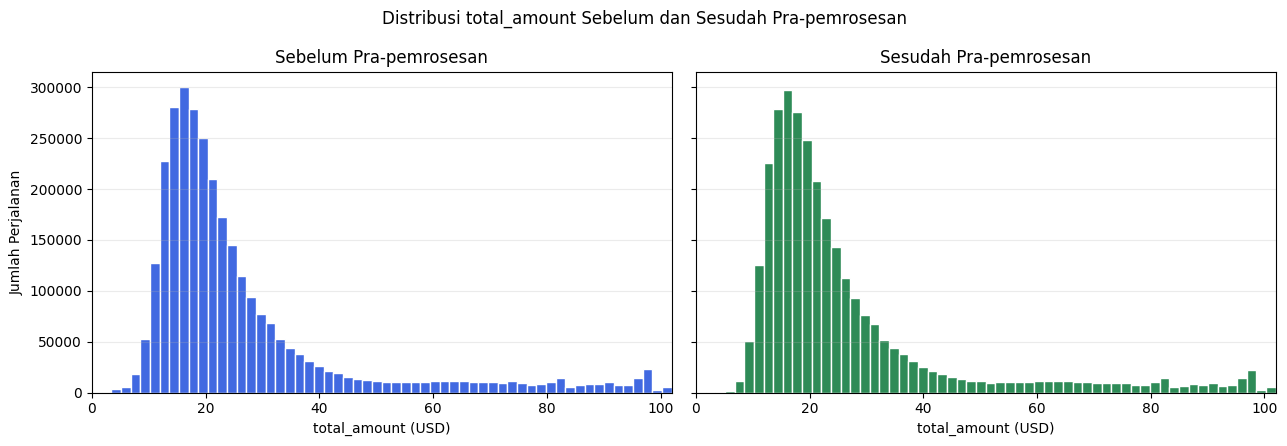

Skewness sebelum: 2.833
Skewness sesudah: 3.026
Grafik tersimpan: /content/drive/MyDrive/BigData/Praktikum3/histogram_total_amount_sebelum_sesudah.png


23

In [22]:
# O.8: Membuat histogram sebelum dan sesudah pra-pemrosesan
import matplotlib.pyplot as plt

total_sebelum = pd.read_parquet(
    PATH_TRIP,
    columns=["total_amount"]
)["total_amount"].dropna()
total_sesudah = bersih["total_amount"].dropna()
batas_x = total_sebelum.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

axes[0].hist(
    total_sebelum, bins=60, range=(0, batas_x),
    color="#4169E1", edgecolor="white"
)
axes[0].set_title("Sebelum Pra-pemrosesan")
axes[0].set_ylabel("Jumlah Perjalanan")

axes[1].hist(
    total_sesudah, bins=60, range=(0, batas_x),
    color="#2E8B57", edgecolor="white"
)
axes[1].set_title("Sesudah Pra-pemrosesan")

for ax in axes:
    ax.set_xlabel("total_amount (USD)")
    ax.set_xlim(0, batas_x)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Distribusi total_amount Sebelum dan Sesudah Pra-pemrosesan")
plt.tight_layout()
path_histogram = f"{DIR_SIMPAN}/histogram_total_amount_sebelum_sesudah.png"
plt.savefig(path_histogram, dpi=200, bbox_inches="tight")
plt.show()

print(f"Skewness sebelum: {total_sebelum.skew():.3f}")
print(f"Skewness sesudah: {total_sesudah.skew():.3f}")
print("Grafik tersimpan:", path_histogram)
del total_sebelum
gc.collect()

### **Pembahasan**

Setelah pra-pemrosesan, bagian transaksi dengan nilai nol atau negatif hilang, tetapi bentuk distribusi tetap miring ke kanan karena perjalanan bertarif tinggi masih dipertahankan sebagai data ekstrem yang mungkin sah. Nilai skewness pada output digunakan untuk mendukung perbandingan bentuk kedua distribusi.

# **P. Studi Kasus: Tabel Analitik untuk Penetapan Harga Dinamis**

Tim pricing membutuhkan satu baris untuk setiap kombinasi borough dan jam. Median digunakan untuk tarif per mil serta kecepatan karena kedua variabel dapat dipengaruhi nilai ekstrem. Kelompok dengan kurang dari 30 perjalanan tidak digunakan agar perbandingan tidak bertumpu pada sampel yang terlalu kecil.

## **P.1. Membentuk dan Menyimpan Tabel Analitik**

Tabel dibentuk dari data `bersih` yang telah memiliki fitur `tarif_per_mil`, `kecepatan_mph`, dan `hujan`. Selain Parquet, dibuat `kamus_data.md` agar definisi, satuan, dan cara penghitungan setiap kolom dapat ditelusuri.

In [23]:
# P.1: Membentuk tabel analitik satu baris per borough per jam
tabel_analitik = (
    bersih
    .assign(
        jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h")
    )
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_tarif_per_mil=("tarif_per_mil", "median"),
        rata_kecepatan=("kecepatan_mph", "median"),
        suhu_c=("suhu_c", "first"),
        hujan=("hujan", "max")
    )
    .reset_index()
)

# Kelompok kecil tidak digunakan untuk penarikan kesimpulan
tabel_analitik = tabel_analitik.loc[
    tabel_analitik["jumlah_perjalanan"] >= 30
].reset_index(drop=True)

PATH_TABEL_ANALITIK = f"{DIR_SIMPAN}/tabel_analitik_pricing.parquet"
PATH_KAMUS_DATA = f"{DIR_SIMPAN}/kamus_data.md"

tabel_analitik.to_parquet(
    PATH_TABEL_ANALITIK,
    index=False
)

isi_kamus = """# Kamus Data Tabel Analitik Pricing

| Kolom | Tipe/Satuan | Definisi dan cara penghitungan |
|---|---|---|
| borough_naik | kategori | Borough lokasi penjemputan dari join PULocationID dengan taxi zone lookup. |
| jam_mulai | datetime, jam lokal New York | Waktu penjemputan yang dibulatkan ke awal jam. |
| jumlah_perjalanan | perjalanan | Jumlah baris perjalanan pada borough dan jam yang sama. Hanya kelompok dengan minimal 30 perjalanan yang disimpan. |
| rata_tarif_per_mil | USD/mil | Median total_amount dibagi trip_distance pada kelompok. Nama kolom dipertahankan mengikuti kebutuhan tim, tetapi statistik yang dipakai adalah median. |
| rata_kecepatan | mil/jam | Median trip_distance dibagi durasi perjalanan dalam jam. |
| suhu_c | derajat Celsius | Nilai suhu pertama pada jam yang sama dari Open-Meteo. |
| hujan | 0 atau 1 | Bernilai 1 apabila hujan_mm pada jam tersebut lebih dari 0,1 mm; selain itu 0. |

## Sumber

NYC TLC Yellow Taxi Trip Records Januari 2023, NYC Taxi Zone Lookup, referensi payment_type, dan Open-Meteo Archive API.
"""

with open(PATH_KAMUS_DATA, "w", encoding="utf-8") as berkas:
    berkas.write(isi_kamus)

lineage[:] = [
    item for item in lineage
    if item["sumber"] != "tabel_analitik_pricing"
]
catat_sumber(
    "tabel_analitik_pricing",
    "hasil kurasi trip + zona + cuaca",
    len(tabel_analitik),
    "Satu baris per borough per jam; minimal 30 perjalanan"
)
pd.DataFrame(lineage).to_csv(
    f"{DIR_SIMPAN}/lineage.csv",
    index=False
)

print("Ukuran tabel analitik:", tabel_analitik.shape)
print("Parquet   :", PATH_TABEL_ANALITIK)
print("Kamus data:", PATH_KAMUS_DATA)
display(tabel_analitik.head())

[lineage] tabel_analitik_pricing: 2,094 baris
Ukuran tabel analitik: (2094, 7)
Parquet   : /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik_pricing.parquet
Kamus data: /content/drive/MyDrive/BigData/Praktikum3/kamus_data.md


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
0,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
1,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
2,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
3,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
4,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0


## **P.2. Membandingkan Tarif pada Jam Hujan dan Tidak Hujan**

Median `rata_tarif_per_mil` dihitung kembali untuk setiap borough dan status hujan. Selisih positif berarti tarif per mil pada kelompok hujan lebih tinggi, tetapi belum membuktikan bahwa hujan menjadi penyebabnya.

In [24]:
# P.2: Membandingkan tarif per mil berdasarkan status hujan
perbandingan_hujan = (
    tabel_analitik
    .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
    .median()
    .unstack()
    .reindex(columns=[0, 1])
    .rename(columns={
        0: "median_tidak_hujan",
        1: "median_hujan"
    })
)

perbandingan_hujan["selisih"] = (
    perbandingan_hujan["median_hujan"]
    - perbandingan_hujan["median_tidak_hujan"]
)
perbandingan_hujan["perubahan_persen"] = (
    100
    * perbandingan_hujan["selisih"]
    / perbandingan_hujan["median_tidak_hujan"]
).round(2)

perbandingan_hujan = perbandingan_hujan.round(3)
display(perbandingan_hujan)

perbandingan_hujan.to_csv(
    f"{DIR_SIMPAN}/perbandingan_tarif_hujan_per_borough.csv"
)

hujan,median_tidak_hujan,median_hujan,selisih,perubahan_persen
borough_naik,,,,
Brooklyn,6.943,7.655,0.712,10.25
Manhattan,10.527,11.400,0.873,8.29
Queens,5.453,5.636,0.183,3.37
Unknown,8.726,9.886,1.160,13.30


## **P.3. Batas Kepercayaan Hasil**

Hasil studi kasus tidak boleh langsung dianggap sebagai dasar perubahan harga karena beberapa keterbatasan berikut.

1. Kolom `rata_tarif_per_mil` sebenarnya menggunakan median, bukan rerata, karena distribusi tarif miring dan mengandung nilai ekstrem. Angka ini mewakili perjalanan tipikal, bukan nilai rata-rata aritmetika.
2. Cuaca diambil dari satu titik koordinat New York City dan diterapkan untuk seluruh borough. Kondisi hujan lokal dapat berbeda dari pengukuran tersebut.
3. Perbandingan ini bersifat korelasional. Hujan dapat terjadi bersamaan dengan jam sibuk, kemacetan, atau perubahan permintaan, sehingga kenaikan tarif tidak dapat dinyatakan disebabkan oleh hujan saja.
4. Kelompok dengan kurang dari 30 perjalanan dihapus. Keputusan ini meningkatkan kestabilan ringkasan, tetapi dapat menghilangkan kondisi langka pada borough dengan volume rendah.
5. Label zona yang kosong dan 37 baris tanpa cuaca perlu diperiksa sebelum analisis yang lebih rinci agar ketidaklengkapan join tidak menghasilkan bias.

## **P.4. Rencana Pembaruan Otomatis Bulanan**

Pembaruan bulanan dapat dijalankan melalui fungsi yang menerima parameter bulan, membentuk URL NYC TLC dan rentang tanggal Open-Meteo, lalu memeriksa apakah partisi bulan tersebut sudah tersedia. Jika belum tersedia, pipeline mengunduh data dengan cache dan retry, menjalankan kontrak kualitas, melakukan join dengan tabel referensi, membentuk fitur, serta menulis hasil ke Parquet berpartisi. Setelah penulisan berhasil, pipeline memperbarui `lineage.csv`, `pengukuran_kinerja.csv`, dan kamus data. Proses dapat dijadwalkan menggunakan scheduler, tetapi publikasi hasil harus dihentikan apabila validasi skema, jumlah baris, atau keunikan kunci gagal.

# **Q. Latihan**

Latihan dikerjakan pada notebook praktikum yang sama setelah K-10. Seluruh hasil pada bagian ini berasal dari eksekusi kode dan tidak digunakan untuk mengganti output langkah K.

## **Q.1. Kecepatan Unduh dan Penggunaan Cache**

Fungsi unduh ditambah pencatatan jumlah byte dan durasi agar kecepatan dapat dihitung dalam MB/detik. Berkas uji khusus latihan dihapus sebelum pemanggilan pertama supaya pemanggilan pertama benar-benar mengunduh, sedangkan pemanggilan kedua memakai cache.

In [25]:
# Q.1: Mengukur kecepatan unduh dan membuktikan penggunaan cache
def unduh_aman_dengan_kecepatan(
    url, tujuan, percobaan=3, jeda_awal=2
):
    if cache_valid(tujuan):
        print("Cache ditemukan:", os.path.basename(tujuan))
        return {"path": tujuan, "memakai_cache": True}

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            waktu_awal = time.perf_counter()
            jumlah_byte = 0

            with requests.get(url, stream=True, timeout=60) as respons:
                respons.raise_for_status()
                with open(sementara, "wb") as berkas:
                    for potongan in respons.iter_content(1024 * 1024):
                        if potongan:
                            berkas.write(potongan)
                            jumlah_byte += len(potongan)

            if jumlah_byte == 0:
                raise IOError("Berkas hasil unduhan kosong")

            os.replace(sementara, tujuan)
            if not cache_valid(tujuan):
                raise IOError("Berkas hasil unduhan tidak dapat dibaca")

            durasi = time.perf_counter() - waktu_awal
            ukuran_mb = jumlah_byte / 1024**2
            kecepatan = ukuran_mb / durasi

            print(
                f"Unduhan selesai: {os.path.basename(tujuan)} | "
                f"{ukuran_mb:.4f} MB | {kecepatan:.2f} MB/detik"
            )
            return {
                "path": tujuan,
                "memakai_cache": False,
                "kecepatan_mb_detik": kecepatan
            }

        except Exception as error:
            if os.path.exists(sementara):
                os.remove(sementara)
            if i == percobaan - 1:
                raise
            jeda = jeda_awal * (2 ** i)
            print(f"Percobaan {i + 1} gagal: {error}")
            time.sleep(jeda)

PATH_UJI_CACHE = os.path.join(
    DIR_MENTAH, "latihan_cache_taxi_zone_lookup.csv"
)

# Hanya menghapus berkas uji latihan, bukan dataset utama
if os.path.exists(PATH_UJI_CACHE):
    os.remove(PATH_UJI_CACHE)

print("Pemanggilan pertama:")
hasil_unduh_1 = unduh_aman_dengan_kecepatan(
    URL_ZONA, PATH_UJI_CACHE
)

print("\nPemanggilan kedua:")
hasil_unduh_2 = unduh_aman_dengan_kecepatan(
    URL_ZONA, PATH_UJI_CACHE
)

print("\nPanggilan kedua memakai cache:", hasil_unduh_2["memakai_cache"])

Pemanggilan pertama:
Unduhan selesai: latihan_cache_taxi_zone_lookup.csv | 0.0118 MB | 0.15 MB/detik

Pemanggilan kedua:
Cache ditemukan: latihan_cache_taxi_zone_lookup.csv

Panggilan kedua memakai cache: True


### **Penjelasan**

Kecepatan dihitung dengan membagi ukuran data yang benar-benar diterima terhadap durasi unduh. Pada pemanggilan kedua, fungsi berhenti setelah `cache_valid()` memastikan berkas tersedia dan dapat dibaca, sehingga tidak ada permintaan unduh baru.

## **Q.2. Dua Aturan Kualitas Tambahan**

Aturan validitas menetapkan `tip_amount` tidak negatif. Aturan konsistensi membandingkan dua kolom dan memeriksa bahwa tip tidak melebihi `total_amount`. Keduanya dilaporkan terpisah agar delapan aturan asli K-6 tetap dapat digunakan pada O.1.

In [26]:
# Q.2: Menambahkan validitas tip dan konsistensi tip dengan total
aturan_tambahan = {
    "validitas: tip_amount >= 0": (
        trip["tip_amount"].notna()
        & (trip["tip_amount"] >= 0)
    ),
    "konsistensi: tip_amount <= total_amount": (
        trip["tip_amount"].notna()
        & trip["total_amount"].notna()
        & (trip["tip_amount"] <= trip["total_amount"])
    )
}

laporan_tambahan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3)
    }
    for nama, mask in aturan_tambahan.items()
])

print("Jumlah baris yang diperiksa:", f"{len(trip):,}")
display(laporan_tambahan)

Jumlah baris yang diperiksa: 3,066,765


,aturan,lulus,gagal,persen_gagal
0,validitas: tip_amount >= 0,3066540,225,0.007
1,konsistensi: tip_amount <= total_amount,3041561,25204,0.822


### **Penjelasan**

Mask Boolean bernilai `True` ketika baris memenuhi aturan. Jumlah gagal diperoleh dari negasi mask, sedangkan persentasenya dibagi dengan jumlah baris `trip` setelah penghapusan satu duplikat kunci pada K-7. Ambang ini merupakan aturan analitis; transaksi koreksi atau pengembalian dana perlu diperiksa sebelum dinyatakan sebagai galat.

## **Q.3. Join Lokasi Tujuan dan Pasangan Borough Tersibuk**

Tabel zona digabungkan kembali menggunakan `DOLocationID`. Validasi `many_to_one` dipertahankan agar setiap lokasi tujuan hanya mempunyai satu pasangan pada tabel referensi.

In [27]:
# Q.3: Menambahkan borough tujuan dan mencari pasangan tersibuk
data_asal_tujuan = (
    bersih.merge(
        zona[["LocationID", "Borough"]].rename(
            columns={"Borough": "borough_turun"}
        ),
        left_on="DOLocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )
    .drop(columns="LocationID")
)

data_asal_tujuan["borough_naik"] = (
    data_asal_tujuan["borough_naik"].fillna("Tidak dikenal")
)
data_asal_tujuan["borough_turun"] = (
    data_asal_tujuan["borough_turun"].fillna("Tidak dikenal")
)

sepuluh_pasangan = (
    data_asal_tujuan
    .groupby(["borough_naik", "borough_turun"], observed=True)
    .size()
    .rename("jumlah_perjalanan")
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

print("Sepuluh pasangan borough asal-tujuan tersibuk:")
display(sepuluh_pasangan)

Sepuluh pasangan borough asal-tujuan tersibuk:


,borough_naik,borough_turun,jumlah_perjalanan
0,Manhattan,Manhattan,2491566
1,Queens,Manhattan,155261
2,Manhattan,Queens,82354
3,Manhattan,Brooklyn,62986
4,Queens,Queens,59146
5,Queens,Brooklyn,42187
6,Unknown,Manhattan,18432
7,Unknown,Unknown,13562
8,Manhattan,Bronx,8865
9,Brooklyn,Brooklyn,7910


### **Penjelasan**

Setelah borough tujuan tersedia, `groupby()` menghitung jumlah perjalanan untuk setiap pasangan asal dan tujuan. Urutan menurun dan `head(10)` memilih sepuluh pasangan dengan volume tertinggi. Nilai `Tidak dikenal` tetap dipertahankan agar kehilangan atribut zona terlihat dan tidak diam-diam dibuang.

## **Q.4. MinMaxScaler dan Perbandingan Rentang**

`MinMaxScaler` dipelajari hanya dari data latih, sama seperti `StandardScaler` pada K-9. Rentang hasil data latih dan data uji kemudian dibandingkan untuk memastikan tidak terjadi kebocoran informasi.

In [28]:
# Q.4: Mengganti StandardScaler dengan MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

skala_minmax = MinMaxScaler().fit(latih[FITUR_NUM])
latih_minmax = skala_minmax.transform(latih[FITUR_NUM])
uji_minmax = skala_minmax.transform(uji[FITUR_NUM])

baris_rentang = []
for indeks, nama_fitur in enumerate(FITUR_NUM):
    baris_rentang.append({
        "fitur": nama_fitur,
        "std_latih_min": latih_num[:, indeks].min(),
        "std_latih_max": latih_num[:, indeks].max(),
        "minmax_latih_min": latih_minmax[:, indeks].min(),
        "minmax_latih_max": latih_minmax[:, indeks].max(),
        "minmax_uji_min": uji_minmax[:, indeks].min(),
        "minmax_uji_max": uji_minmax[:, indeks].max()
    })

perbandingan_scaler = pd.DataFrame(baris_rentang).round(3)
display(perbandingan_scaler)

print("Rentang MinMax data latih mendekati 0 sampai 1.")
print("Data uji dapat berada di luar rentang karena scaler hanya fit pada data latih.")

,fitur,std_latih_min,std_latih_max,minmax_latih_min,minmax_latih_max,minmax_uji_min,minmax_uji_max
0,trip_distance_capped,-0.794,4.247,0.0,1.0,0.0,1.00
1,durasi_menit,-1.226,13.925,0.0,1.0,0.0,0.91
2,suhu_c,-2.288,3.347,0.0,1.0,0.0,1.00


Rentang MinMax data latih mendekati 0 sampai 1.
Data uji dapat berada di luar rentang karena scaler hanya fit pada data latih.


### **Penjelasan**

`StandardScaler` memusatkan data terhadap rata-rata dan mengubah skala berdasarkan simpangan baku, sedangkan `MinMaxScaler` memetakan rentang data latih ke 0-1. Perbedaan skala penting bagi algoritma berbasis jarak atau gradien, seperti KNN, SVM, regresi dengan regularisasi, dan jaringan saraf. Model berbasis pohon keputusan umumnya tidak sensitif terhadap perubahan skala monoton karena pemisahannya menggunakan urutan nilai dan ambang.

## **Q.5. Membuktikan Validasi `many_to_one`**

Satu baris tabel zona digandakan pada salinan sementara. Join sengaja dijalankan dengan `validate="many_to_one"` dan error ditangkap agar eksekusi notebook tetap berlanjut. Tabel `zona` asli tidak diubah.

In [29]:
# Q.5: Membuktikan bahwa many_to_one menolak kunci referensi ganda
zona_duplikat = pd.concat(
    [zona.copy(), zona.iloc[[0]].copy()],
    ignore_index=True
)

print("Kunci zona asli unik?     ", zona["LocationID"].is_unique)
print("Kunci salinan masih unik?", zona_duplikat["LocationID"].is_unique)

try:
    bersih[["PULocationID"]].head(1000).merge(
        zona_duplikat[["LocationID", "Borough"]],
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )
    raise AssertionError("Join seharusnya gagal karena kunci kanan tidak unik.")
except pd.errors.MergeError as error:
    print("\nError yang diharapkan:")
    print(error)
finally:
    del zona_duplikat

print("\nTabel zona dikembalikan ke kondisi awal:", zona["LocationID"].is_unique)

Kunci zona asli unik?      True
Kunci salinan masih unik? False

Error yang diharapkan:
Merge keys are not unique in right dataset; not a many-to-one merge

Tabel zona dikembalikan ke kondisi awal: True


### **Penjelasan**

Relasi `many_to_one` mengizinkan banyak perjalanan mempunyai LocationID yang sama, tetapi tabel referensi di sisi kanan wajib memiliki satu baris untuk setiap LocationID. Ketika satu kunci digandakan, pandas memunculkan `MergeError`. Pengujian memakai salinan sehingga tabel zona asli tetap unik setelah sel selesai.

## **Q.6. Pipeline Inkremental dan Idempotensi**

Fungsi menerima bulan dalam format `YYYY-MM`. Sebelum mengunduh atau memproses data, fungsi memeriksa apakah berkas keluaran bulan tersebut sudah ada. Penulisan dilakukan melalui berkas sementara agar hasil setengah jadi tidak dianggap sebagai keluaran yang sah.

In [30]:
# Q.6: Memproses hanya bulan yang belum tersedia
DIR_INKREMENTAL = os.path.join(DIR_KURASI, "inkremental")
os.makedirs(DIR_INKREMENTAL, exist_ok=True)

def siapkan_cuaca_bulan(periode):
    data_cuaca = ambil_cuaca(
        periode.start_time.strftime("%Y-%m-%d"),
        periode.end_time.strftime("%Y-%m-%d")
    )
    data_cuaca["time"] = pd.to_datetime(
        data_cuaca["time"], errors="coerce"
    )
    if data_cuaca["time"].isna().any():
        raise ValueError("Waktu cuaca gagal dikonversi.")
    return data_cuaca.rename(columns={
        "time": "jam_mulai",
        "temperature_2m": "suhu_c",
        "precipitation": "hujan_mm"
    })

def pipeline_inkremental(bulan):
    periode = pd.Period(bulan, freq="M")
    nama_bulan = periode.strftime("%Y-%m")
    path_output = os.path.join(
        DIR_INKREMENTAL,
        f"trips_bersih_{nama_bulan}.parquet"
    )

    if os.path.exists(path_output):
        print(f"Lewati {nama_bulan}: keluaran sudah tersedia.")
        return {
            "bulan": nama_bulan,
            "status": "cache",
            "path": path_output
        }

    url_bulan = (
        "https://d37ci6vzurychx.cloudfront.net/trip-data/"
        f"yellow_tripdata_{nama_bulan}.parquet"
    )
    path_mentah_bulan = os.path.join(
        DIR_MENTAH, f"yellow_tripdata_{nama_bulan}.parquet"
    )

    unduh_aman(url_bulan, path_mentah_bulan)
    cuaca_bulan = siapkan_cuaca_bulan(periode)
    hasil_bulan = pipeline(
        path_mentah_bulan,
        PATH_ZONA,
        cuaca_bulan,
        tarif_referensi
    )
    hasil_bulan["bulan_sumber"] = nama_bulan

    path_sementara = path_output + ".part"
    hasil_bulan.to_parquet(path_sementara, index=False)
    os.replace(path_sementara, path_output)

    catat_sumber(
        f"trip_{nama_bulan}",
        url_bulan,
        len(hasil_bulan),
        "Hasil pipeline inkremental bulanan"
    )
    pd.DataFrame(lineage).to_csv(
        f"{DIR_SIMPAN}/lineage.csv", index=False
    )

    jumlah_baris = len(hasil_bulan)
    del hasil_bulan
    gc.collect()

    print(f"Selesai {nama_bulan}: {jumlah_baris:,} baris.")
    return {
        "bulan": nama_bulan,
        "status": "dibuat",
        "path": path_output
    }

bulan_uji = "2023-01"
hasil_pertama = pipeline_inkremental(bulan_uji)
berkas_setelah_pertama = sorted(os.listdir(DIR_INKREMENTAL))
waktu_ubah_pertama = os.path.getmtime(hasil_pertama["path"])

hasil_kedua = pipeline_inkremental(bulan_uji)
berkas_setelah_kedua = sorted(os.listdir(DIR_INKREMENTAL))
waktu_ubah_kedua = os.path.getmtime(hasil_kedua["path"])

idempoten = (
    berkas_setelah_pertama == berkas_setelah_kedua
    and waktu_ubah_pertama == waktu_ubah_kedua
)

print("\nStatus pemanggilan pertama:", hasil_pertama["status"])
print("Status pemanggilan kedua  :", hasil_kedua["status"])
print(
    "Berkas baru pada panggilan kedua:",
    len(berkas_setelah_kedua) - len(berkas_setelah_pertama)
)
print("Pipeline idempoten:", idempoten)

Cache ditemukan: yellow_tripdata_2023-01.parquet
Validasi lulus: 2,986,910 baris x 17 kolom
[lineage] trip_2023-01: 2,986,910 baris
Selesai 2023-01: 2,986,910 baris.
Lewati 2023-01: keluaran sudah tersedia.

Status pemanggilan pertama: dibuat
Status pemanggilan kedua  : cache
Berkas baru pada panggilan kedua: 0
Pipeline idempoten: True


### **Penjelasan**

Pemeriksaan keluaran dilakukan sebelum unduhan sehingga bulan yang sudah selesai tidak diproses ulang. Pemanggilan kedua harus berstatus `cache`, jumlah berkas baru harus nol, dan waktu modifikasi berkas harus tetap sama. Inilah bukti idempotensi: input serta parameter yang sama tidak mengubah hasil yang sudah tersedia.

> Bagian R atau Tugas Praktikum tidak dimasukkan di notebook ini karena harus dikerjakan pada notebook terpisah.